# MCO2 Numerical Data Analysis Notebook

## TODO (delete when done): 
- [X] Reorganize statistical analyses according to hypotheses
- [X] Ensure that the confidence levels here follow the one in our paper. 
- [X] Report ANVOA results properly (follow the one in the PPT):
- [X] Generate a master table of all the relevant ANOVA results to place in the paper.
- [X] Check for normality of data.
- [X] Double check all the tests that we claimed to do on the paper and verify if we still need to do them.
- [X] Try the bar chart with whiskers as representation (make sure the variables are on the same scale / unit though!)
- [ ] Organize results folder into csvs and visualizations

## Variables and Areas for Exploration
Independent Variables (What we control): Keyboard Size, Task Type
Dependent Variables: NASA-TLX scores. Typing Performance. 

We can explore relationship between...
- Keyboard Size and NASA-TLX Scores
- Task Type and NASA-TLX Score.
- Keyboard Size and Typing Performance.
- Task Type and Typing Performance.
- Keyboard Size + Task Type versus NASA-TLX.
- Keyboard Size + Task Type versus Typing Performance. 
- Correlate KB Size + Task Type versus NASA-TLX and versus Typing Performance.

## Setup

Import dependencies

In [217]:
# %pip install "numpy<2.0"
# pip install pingouin

In [218]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.anova import anova_lm
from scipy.stats import shapiro

In [219]:
sns.set_theme(style="whitegrid", context="notebook")


Load CSVs

In [220]:
typing_test_df = pd.read_csv('typing_test_data.csv')
nasa_tlx_df = pd.read_csv('nasa_tlx.csv')

## Exploratory Data Analysis

### Exploring `typing_test_data.csv`

In [221]:
typing_test_df

,Participant Number,GroupNumber,Text_60_WPM,Text_60_Accuracy,Text_60_ErrorRate,Text_60_MouseTime,Text_60_Clicks,Text_60_Backspaces,Text_60_Scrolls,Text_60_TotalTime,...,Prog_100_Accuracy,Prog_100_ErrorRate,Prog_100_MouseTime,Prog_100_Clicks,Prog_100_Backspaces,Prog_100_Scrolls,Prog_100_TotalTime,Prog_100_CorrectChars,Prog_100_IncorrectFixed,Prog_100_IncorrectNotFixed
0,2,2,89.0,92.4,7.6,0.045,0,25,0,40.982,...,83.5,16.8,2.184,1,66,4,113.118,327,66,0
1,3,3,73.7,84.9,15.1,0.000,0,54,0,49.531,...,85.4,14.2,0.000,0,54,0,64.878,327,54,0
2,4,4,61.7,89.6,10.4,0.000,0,40,0,67.079,...,94.3,6.0,0.000,0,18,0,67.785,281,18,0
3,5,5,68.8,93.5,6.5,0.000,0,24,0,60.183,...,90.9,9.1,0.000,0,28,0,102.489,281,28,0
4,12,6,53.1,93.8,6.2,0.000,0,23,0,77.976,...,66.9,12.0,0.000,0,29,0,120.000,213,29,0
5,11,5,57.1,95.6,4.4,0.000,0,16,0,72.495,...,56.4,10.6,0.000,0,26,0,120.000,244,26,3
6,7,1,82.0,92.7,7.3,0.000,0,24,0,44.502,...,89.3,10.7,0.000,0,39,0,66.300,327,39,0
7,8,2,66.9,90.4,9.0,0.000,0,30,0,54.191,...,89.7,9.2,0.000,0,33,0,94.726,327,33,0
8,9,3,70.1,94.7,5.3,3.009,1,17,0,52.004,...,89.1,10.9,0.000,0,40,0,91.309,327,40,0
9,13,1,55.2,94.7,5.3,0.000,0,17,0,66.053,...,85.4,14.6,0.000,0,56,0,112.535,327,56,0


In [222]:
typing_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 68 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Participant Number          33 non-null     int64  
 1   GroupNumber                 33 non-null     int64  
 2   Text_60_WPM                 33 non-null     float64
 3   Text_60_Accuracy            33 non-null     float64
 4   Text_60_ErrorRate           33 non-null     float64
 5   Text_60_MouseTime           33 non-null     float64
 6   Text_60_Clicks              33 non-null     int64  
 7   Text_60_Backspaces          33 non-null     int64  
 8   Text_60_Scrolls             33 non-null     int64  
 9   Text_60_TotalTime           33 non-null     float64
 10  Text_60_CorrectChars        33 non-null     int64  
 11  Text_60_IncorrectFixed      33 non-null     int64  
 12  Text_60_IncorrectNotFixed   33 non-null     int64  
 13  Num_60_WPM                  33 non-nu

In [223]:
typing_test_df.describe()

,Participant Number,GroupNumber,Text_60_WPM,Text_60_Accuracy,Text_60_ErrorRate,Text_60_MouseTime,Text_60_Clicks,Text_60_Backspaces,Text_60_Scrolls,Text_60_TotalTime,...,Prog_100_Accuracy,Prog_100_ErrorRate,Prog_100_MouseTime,Prog_100_Clicks,Prog_100_Backspaces,Prog_100_Scrolls,Prog_100_TotalTime,Prog_100_CorrectChars,Prog_100_IncorrectFixed,Prog_100_IncorrectNotFixed
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.0,33.000000,...,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,17.242424,3.333333,69.278788,92.275758,7.800000,0.519636,0.272727,27.363636,0.0,60.855515,...,86.800000,11.339394,0.448848,0.484848,37.878788,0.121212,97.962848,292.030303,37.878788,0.333333
std,10.059294,1.670828,18.638162,3.520035,3.959561,2.157308,1.097518,14.039716,0.0,19.694996,...,7.954676,4.305588,1.675085,1.954501,16.661628,0.696311,20.362716,32.043413,16.661628,0.853913
min,1.000000,1.000000,34.200000,82.600000,3.600000,0.000000,0.000000,12.000000,0.0,34.316000,...,56.400000,3.400000,0.000000,0.000000,10.000000,0.000000,63.357000,213.000000,10.000000,0.000000
25%,9.000000,2.000000,56.500000,90.400000,5.000000,0.000000,0.000000,17.000000,0.0,49.666000,...,84.500000,9.100000,0.000000,0.000000,26.000000,0.000000,79.323000,281.000000,26.000000,0.000000
50%,17.000000,3.000000,69.800000,93.500000,6.500000,0.000000,0.000000,24.000000,0.0,57.928000,...,88.100000,10.900000,0.000000,0.000000,35.000000,0.000000,103.653000,281.000000,35.000000,0.000000
75%,25.000000,5.000000,82.000000,95.000000,9.300000,0.000000,0.000000,32.000000,0.0,68.168000,...,90.900000,14.200000,0.000000,0.000000,52.000000,0.000000,120.000000,327.000000,52.000000,0.000000
max,35.000000,6.000000,106.000000,96.400000,21.700000,12.020000,6.000000,70.000000,0.0,120.000000,...,96.600000,22.400000,9.251000,11.000000,70.000000,4.000000,120.000000,327.000000,70.000000,3.000000


### Exploring `nasa_tlx.csv`

#### Typing test dataset: structural overview


In [224]:
typing_structure = (
    pd.DataFrame({
        "dtype": typing_test_df.dtypes,
        "unique": typing_test_df.nunique(),
        "missing": typing_test_df.isna().sum(),
    })
    .sort_values("unique", ascending=False)
)
typing_structure.head(10)


,dtype,unique,missing
Participant Number,int64,33,0
Text_60_TotalTime,float64,33,0
Num_100_WPM,float64,33,0
Text_100_TotalTime,float64,33,0
Text_100_WPM,float64,33,0
Num_60_WPM,float64,33,0
Prog_100_WPM,float64,32,0
Prog_60_WPM,float64,32,0
Text_60_WPM,float64,32,0
Prog_100_Accuracy,float64,31,0


#### Typing test dataset: key performance metrics


In [225]:
wpm_cols = [
    "Text_60_WPM",
    "Num_60_WPM",
    "Prog_60_WPM",
    "Text_100_WPM",
    "Num_100_WPM",
    "Prog_100_WPM",
]
accuracy_cols = [
    "Text_60_Accuracy",
    "Num_60_Accuracy",
    "Prog_60_Accuracy",
    "Text_100_Accuracy",
    "Num_100_Accuracy",
    "Prog_100_Accuracy",
]
key_metrics = (
    typing_test_df[wpm_cols + accuracy_cols]
    .agg(["mean", "std", "min", "max"])
    .T.round(2)
)
key_metrics


,mean,std,min,max
Text_60_WPM,69.28,18.64,34.2,106.0
Num_60_WPM,29.19,8.99,8.9,46.6
Prog_60_WPM,38.38,12.65,3.9,59.3
Text_100_WPM,70.31,19.48,32.2,101.0
Num_100_WPM,29.54,7.74,16.3,45.3
Prog_100_WPM,37.38,11.93,15.4,61.9
Text_60_Accuracy,92.28,3.52,82.6,96.4
Num_60_Accuracy,85.94,10.08,37.7,95.1
Prog_60_Accuracy,87.87,13.73,14.9,97.6
Text_100_Accuracy,90.99,4.69,81.6,98.1


#### Typing test dataset: group-level WPM comparison


In [226]:
group_wpm_summary = (
    typing_test_df.groupby("GroupNumber")[wpm_cols]
    .agg(["mean", "std"])
    .round(2)
)
group_wpm_summary


Text_60_WPM        Num_60_WPM        Prog_60_WPM         \
                   mean    std       mean    std        mean    std   
GroupNumber                                                           
1                 65.67  24.41      25.15  12.71       38.10  20.92   
2                 70.98  20.58      26.48   8.01       36.10   8.53   
3                 75.86  26.57      35.68  11.74       41.46  13.51   
4                 67.40   8.88      29.84   3.90       38.79   8.43   
5                 72.16  10.28      31.14   7.46       42.70  11.68   
6                 63.60  24.44      27.62   8.38       32.22  13.48   

            Text_100_WPM        Num_100_WPM        Prog_100_WPM         
                    mean    std        mean    std         mean    std  
GroupNumber                                                             
1                  66.38  20.16       32.57  10.23        43.95  14.97  
2                  64.40  21.44       27.47   7.55        35.07   9.55  
3                  71.72  24.72       34.68  11.20        44.72  13.38  
4                  75.69  17.95       27.13   5.55        36.41   7.95  
5                  76.54  16.65       29.42   2.92        33.64  11.96  
6                  66.08  22.68       26.08   5.45        28.22  10.63

#### Typing test dataset: WPM distributions


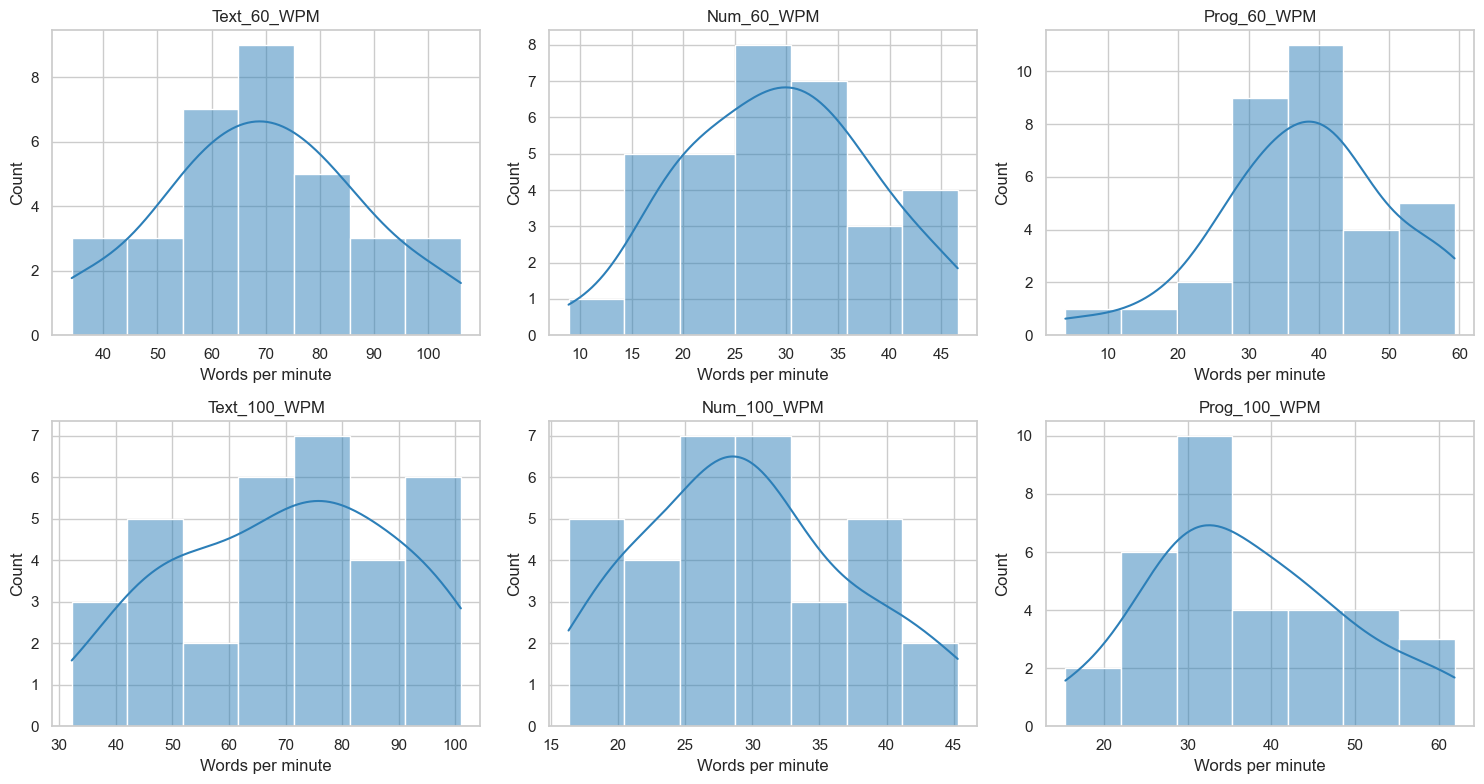

In [227]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for col, ax in zip(wpm_cols, axes.ravel()):
    sns.histplot(typing_test_df[col], kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(col)
    ax.set_xlabel("Words per minute")
plt.tight_layout()


#### Typing test dataset: correlation between WPM and accuracy


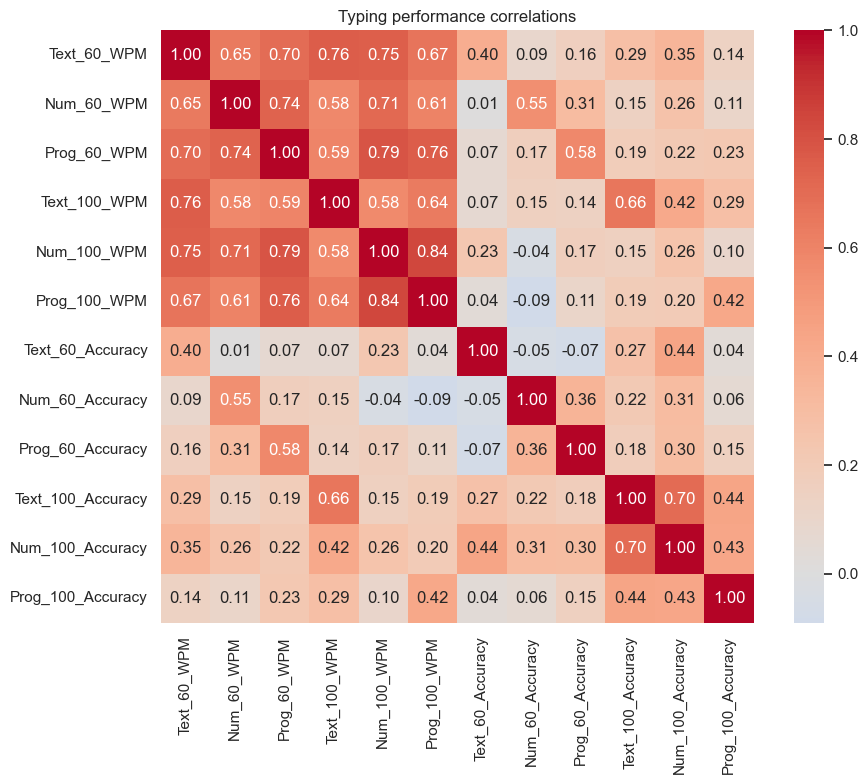

In [228]:
corr_cols = wpm_cols + accuracy_cols
corr_matrix = typing_test_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Typing performance correlations")
plt.tight_layout()


In [229]:
nasa_tlx_df

,Participant Number,Original Keyboard,Keyboard Type,Task Type,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
0,15,Both,1,A,1,1,1,10,1,1
1,15,Both,1,B,7,8,4,5,5,2
2,15,Both,1,C,3,6,1,5,4,2
3,15,Both,2,A,1,1,1,7,1,1
4,15,Both,2,B,6,9,3,5,6,2
...,...,...,...,...,...,...,...,...,...,...
193,10,60,1,B,6,5,6,4,6,5
194,10,60,1,C,5,4,5,5,5,5
195,10,60,2,A,3,4,4,6,4,2
196,10,60,2,B,8,4,6,4,6,5


In [230]:
nasa_tlx_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Participant Number  198 non-null    int64 
 1   Original Keyboard   198 non-null    object
 2   Keyboard Type       198 non-null    int64 
 3   Task Type           198 non-null    object
 4   Mental Demand       198 non-null    int64 
 5   Physical Demand     198 non-null    int64 
 6   Temporal Demand     198 non-null    int64 
 7   Performance         198 non-null    int64 
 8   Effort              198 non-null    int64 
 9   Frustration Level   198 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 15.6+ KB


In [231]:
nasa_tlx_df.describe()

,Participant Number,Keyboard Type,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,17.000000,1.500000,4.318182,3.969697,4.176768,6.853535,4.444444,3.323232
std,9.546041,0.501267,2.092960,2.165510,2.406435,2.235787,2.283119,2.307913
min,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000
25%,9.000000,1.000000,3.000000,2.000000,2.000000,5.000000,3.000000,2.000000
50%,17.000000,1.500000,4.000000,4.000000,4.000000,7.000000,4.000000,2.000000
75%,25.000000,2.000000,6.000000,6.000000,6.000000,9.000000,6.000000,4.000000
max,33.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


#### NASA TLX dataset: categorical overview


In [232]:
category_counts = {
    "Keyboard Type": nasa_tlx_df["Keyboard Type"].value_counts().sort_index(),
    "Task Type": nasa_tlx_df["Task Type"].value_counts().sort_index(),
    "Original Keyboard": nasa_tlx_df["Original Keyboard"].value_counts().sort_values(ascending=False).head(5),
}
for label, series in category_counts.items():
    display(pd.DataFrame(series).rename(columns={series.name: "count"}))


,count
Keyboard Type,
1,99
2,99


,count
Task Type,
A,66
B,66
C,66


,count
Original Keyboard,
100,66
60,48
Laptop,24
75,24
Both,6


#### NASA TLX dataset: workload scores by keyboard and task


In [233]:
workload_cols = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level",
]
keyboard_summary = nasa_tlx_df.groupby("Keyboard Type")[workload_cols].mean().round(2)
task_summary = nasa_tlx_df.groupby("Task Type")[workload_cols].mean().round(2)
keyboard_summary, task_summary


(               Mental Demand  Physical Demand  Temporal Demand  Performance  \
 Keyboard Type                                                                 
 1                       4.47             4.07             4.18         6.81   
 2                       4.16             3.87             4.17         6.90   
 
                Effort  Frustration Level  
 Keyboard Type                             
 1                4.64               3.39  
 2                4.25               3.25  ,
            Mental Demand  Physical Demand  Temporal Demand  Performance  \
 Task Type                                                                 
 A                   3.21             3.05             3.23         7.88   
 B                   5.62             4.83             5.36         5.61   
 C                   4.12             4.03             3.94         7.08   
 
            Effort  Frustration Level  
 Task Type                             
 A            3.42               2.30  

#### NASA TLX dataset: workload distributions


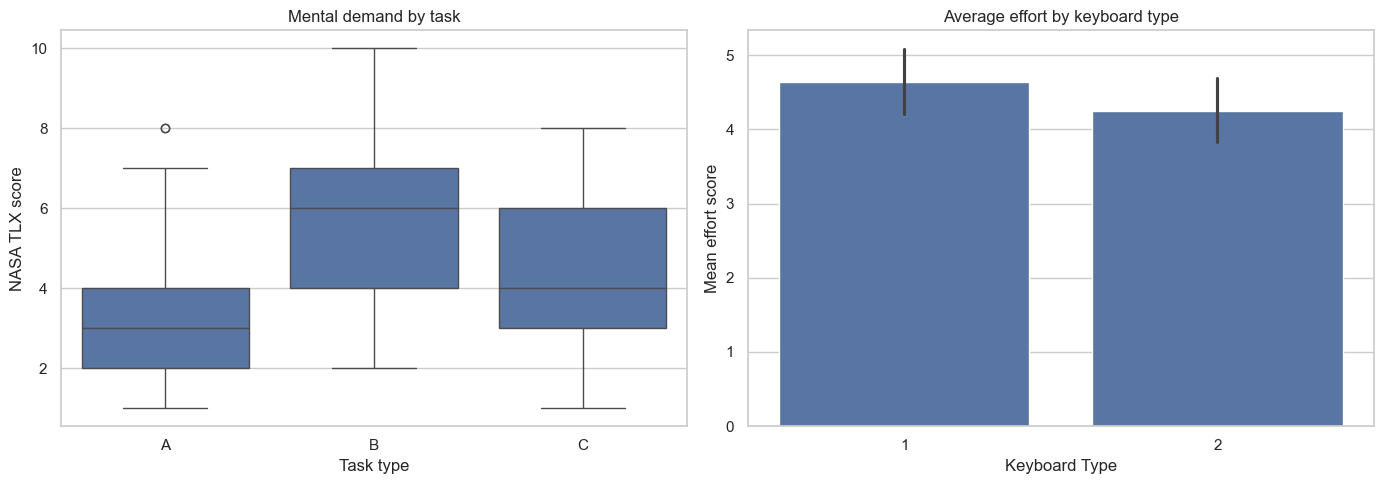

In [234]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Removed explicit palette without hue to avoid seaborn deprecation warnings.
sns.boxplot(data=nasa_tlx_df, x="Task Type", y="Mental Demand", ax=axes[0])
axes[0].set_title("Mental demand by task")
axes[0].set_xlabel("Task type")
axes[0].set_ylabel("NASA TLX score")

sns.barplot(
    data=nasa_tlx_df,
    x="Keyboard Type",
    y="Effort",
    estimator=np.mean,
    errorbar=("ci", 95),
    ax=axes[1],
)
axes[1].set_title("Average effort by keyboard type")
axes[1].set_ylabel("Mean effort score")
plt.tight_layout()


#### Takeaways
- Typing performance varies widely (Text_60_WPM ranges from the mid-30s to 100+ WPM) yet accuracies remain clustered above 80%. Higher WPM tasks (e.g., Text_100) introduce broader variance, especially for numerical/programming passages.
- Group-level summaries suggest Groups 3–4 generally have the fastest typing speeds in both 60 and 100 WPM tasks, whereas Groups 1–2 show more dispersion.
- Correlation analysis shows positive relationships between each mode's WPM and accuracy, indicating faster typists in this sample also tend to stay accurate; programming tasks at 100 WPM are the most weakly correlated with their 60 WPM counterparts, hinting at modality-specific skills.
- NASA TLX scores skew toward moderate workloads (means ~4–5), but Task Type B elicits noticeably higher mental demand and effort across keyboard types.
- Keyboard Type 2 scenarios trend toward higher effort/frustration than Type 1, and workload dimensions are strongly interrelated (e.g., effort/frustration correlation >0.8).


#### NASA TLX dataset: correlation between workload dimensions


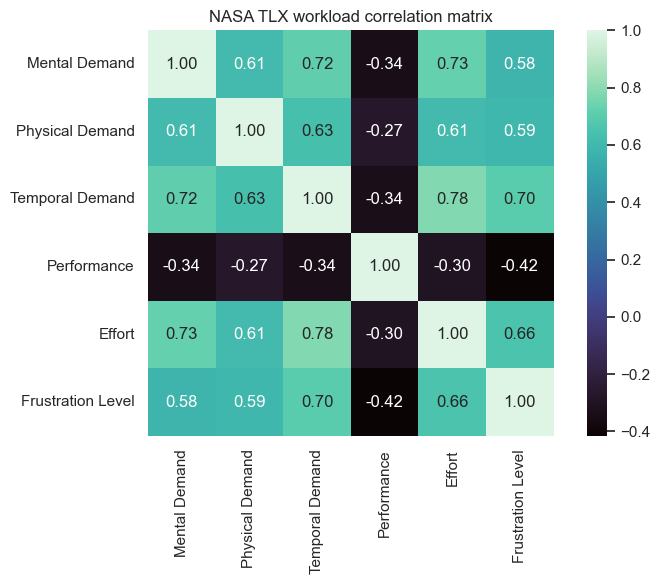

In [235]:
nasa_corr = nasa_tlx_df[workload_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(nasa_corr, cmap="mako", annot=True, fmt=".2f", square=True)
plt.title("NASA TLX workload correlation matrix")
plt.tight_layout()


## Setting up dataset with preference matching

In [236]:
task_meta = {
    "Text": {"code": "A", "label": "Task A · Text Entry"},
    "Num": {"code": "B", "label": "Task B · Number Entry"},
    "Prog": {"code": "C", "label": "Task C · Programming"},
}
keyboard_meta_perf = {"60": "KB1 (60%)", "100": "KB2 (100%)"}
perf_metrics = [
    "WPM",
    "Accuracy",
    "ErrorRate",
    "MouseTime",
    "Clicks",
    "Backspaces",
    "Scrolls",
    "TotalTime",
    "CorrectChars",
    "IncorrectFixed",
    "IncorrectNotFixed",
]

perf_long = []
for task_prefix, task_info in task_meta.items():
    for kb_suffix, kb_label in keyboard_meta_perf.items():
        col_map = {metric: f"{task_prefix}_{kb_suffix}_{metric}" for metric in perf_metrics}
        available_cols = [col for col in col_map.values() if col in typing_test_df.columns]
        if len(available_cols) != len(perf_metrics):
            missing = sorted(set(col_map.values()) - set(available_cols))
            raise ValueError(f"Missing columns for {task_prefix} {kb_suffix}: {missing}")

        subset = typing_test_df[["Participant Number", "GroupNumber"] + available_cols].copy()
        subset = subset.rename(columns={v: k for k, v in col_map.items()})
        subset["Keyboard"] = kb_label
        subset["Task"] = task_info["label"]
        subset["TaskCode"] = task_info["code"]
        perf_long.append(subset)

perf_long = pd.concat(perf_long, ignore_index=True)
perf_long.head()

,Participant Number,GroupNumber,WPM,Accuracy,ErrorRate,MouseTime,Clicks,Backspaces,Scrolls,TotalTime,CorrectChars,IncorrectFixed,IncorrectNotFixed,Keyboard,Task,TaskCode
0,2,2,89.0,92.4,7.6,0.045,0,25,0,40.982,304,25,0,KB1 (60%),Task A · Text Entry,A
1,3,3,73.7,84.9,15.1,0.000,0,54,0,49.531,304,54,0,KB1 (60%),Task A · Text Entry,A
2,4,4,61.7,89.6,10.4,0.000,0,40,0,67.079,345,40,0,KB1 (60%),Task A · Text Entry,A
3,5,5,68.8,93.5,6.5,0.000,0,24,0,60.183,345,24,0,KB1 (60%),Task A · Text Entry,A
4,12,6,53.1,93.8,6.2,0.000,0,23,0,77.976,345,23,0,KB1 (60%),Task A · Text Entry,A


### Keyboard-Task Combo versus NASA-TLX Dimensions

In [237]:
keyboard_meta_tlx = {1: "KB1 (60%)", 2: "KB2 (100%)"}
task_label_map = {meta["code"]: meta["label"] for meta in task_meta.values()}

nasa_aug = nasa_tlx_df.copy()
nasa_aug["Keyboard"] = nasa_aug["Keyboard Type"].map(keyboard_meta_tlx)
nasa_aug["Task"] = nasa_aug["Task Type"].map(task_label_map)
nasa_aug["Overall Score"] = nasa_aug[workload_cols].mean(axis=1)

nasa_summary = (
    nasa_aug.groupby(["Keyboard", "Task"])[["Overall Score"] + workload_cols]
    .agg(["mean", "std"])
    .round(2)
)
nasa_summary


Overall Score       Mental Demand        \
                                          mean   std          mean   std   
Keyboard   Task                                                            
KB1 (60%)  Task A · Text Entry            3.95  1.32          3.42  1.92   
           Task B · Number Entry          5.25  1.57          5.73  2.07   
           Task C · Programming           4.58  1.32          4.27  1.61   
KB2 (100%) Task A · Text Entry            3.75  1.24          3.00  1.62   
           Task B · Number Entry          5.24  1.48          5.52  1.95   
           Task C · Programming           4.31  1.43          3.97  1.93   

                                 Physical Demand       Temporal Demand        \
                                            mean   std            mean   std   
Keyboard   Task                                                                
KB1 (60%)  Task A · Text Entry              3.12  1.65            3.24  2.24   
           Task B · Number Entry            4.76  2.25            5.24  2.70   
           Task C · Programming             4.33  2.20            4.06  2.08   
KB2 (100%) Task A · Text Entry              2.97  1.67            3.21  2.03   
           Task B · Number Entry            4.91  2.35            5.48  2.29   
           Task C · Programming             3.73  2.10            3.82  2.17   

                                 Performance       Effort        \
                                        mean   std   mean   std   
Keyboard   Task                                                   
KB1 (60%)  Task A · Text Entry          7.88  2.04   3.67  2.20   
           Task B · Number Entry        5.42  2.08   5.73  2.34   
           Task C · Programming         7.12  2.06   4.52  2.03   
KB2 (100%) Task A · Text Entry          7.88  1.98   3.18  1.91   
           Task B · Number Entry        5.79  1.92   5.58  2.03   
           Task C · Programming         7.03  2.21   4.00  2.09   

                                 Frustration Level        
                                              mean   std  
Keyboard   Task                                           
KB1 (60%)  Task A · Text Entry                2.36  1.76  
           Task B · Number Entry              4.64  2.86  
           Task C · Programming               3.18  1.74  
KB2 (100%) Task A · Text Entry                2.24  1.66  
           Task B · Number Entry              4.18  2.30  
           Task C · Programming               3.33  2.39

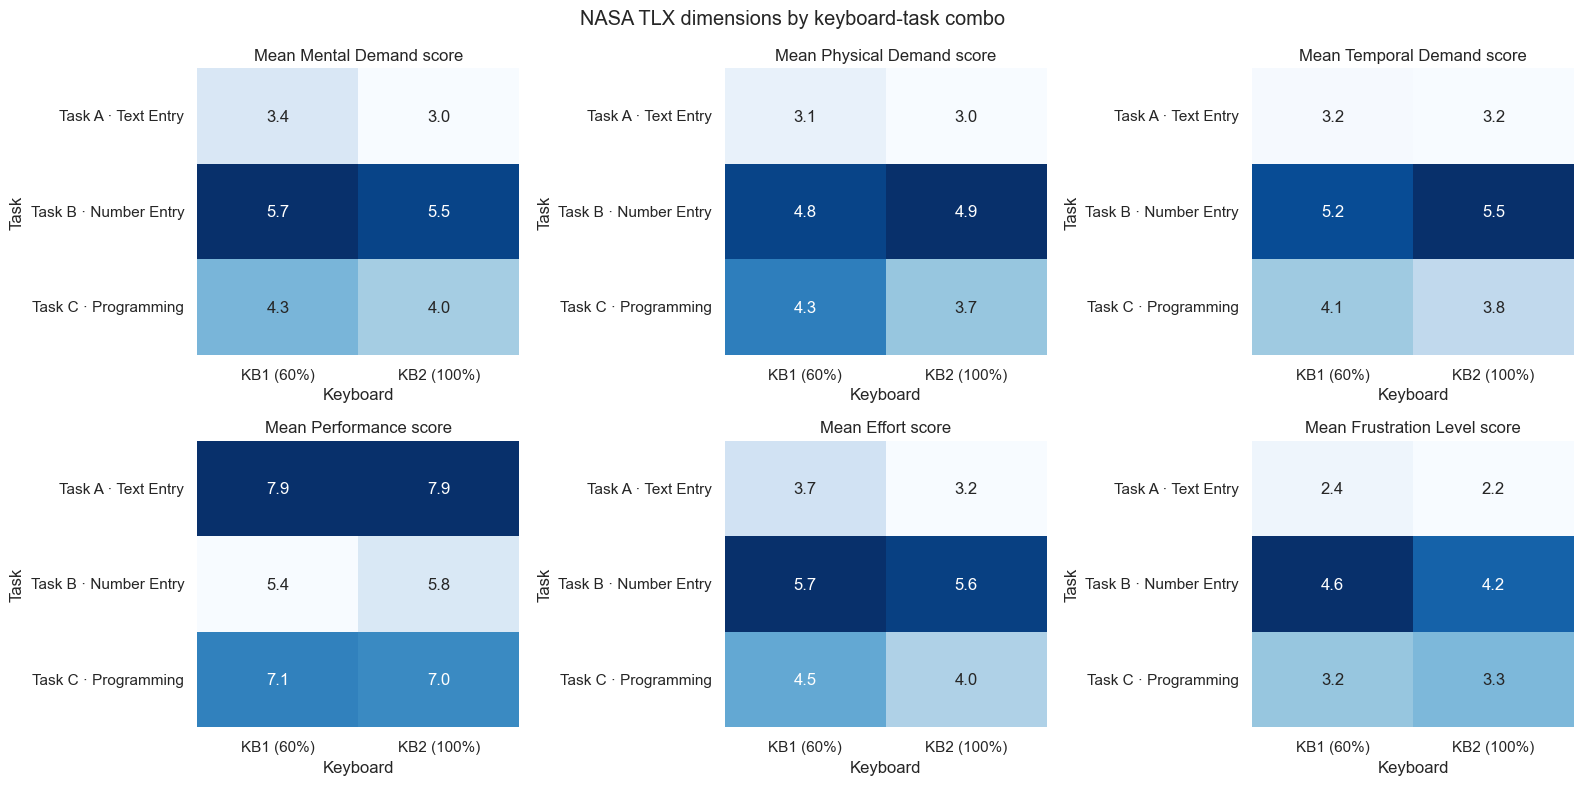

Keyboard,KB1 (60%),KB2 (100%)
Task,,
Task A · Text Entry,3.95,3.75
Task B · Number Entry,5.25,5.24
Task C · Programming,4.58,4.31


In [238]:
overall_pivot = nasa_aug.pivot_table(
    index="Task",
    columns="Keyboard",
    values="Overall Score",
    aggfunc="mean",
).round(2)

dimension_pivots = {
    dim: nasa_aug.pivot_table(index="Task", columns="Keyboard", values=dim, aggfunc="mean").round(2)
    for dim in workload_cols
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (dim, pivot) in zip(axes.ravel(), dimension_pivots.items()):
    sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".1f", ax=ax, cbar=False)
    ax.set_title(f"Mean {dim} score")
    ax.set_xlabel("Keyboard")
    ax.set_ylabel("Task")
plt.suptitle("NASA TLX dimensions by keyboard-task combo")
plt.tight_layout()
plt.show()

overall_pivot


#### Correlation across performance and NASA-TLX dependent variables
By pairing each participant's typing metrics with their NASA-TLX ratings per keyboard-task combination, we can inspect how objective performance covaries with perceived workload. The heatmap below spans WPM, Accuracy, ErrorRate, and the six TLX dimensions.

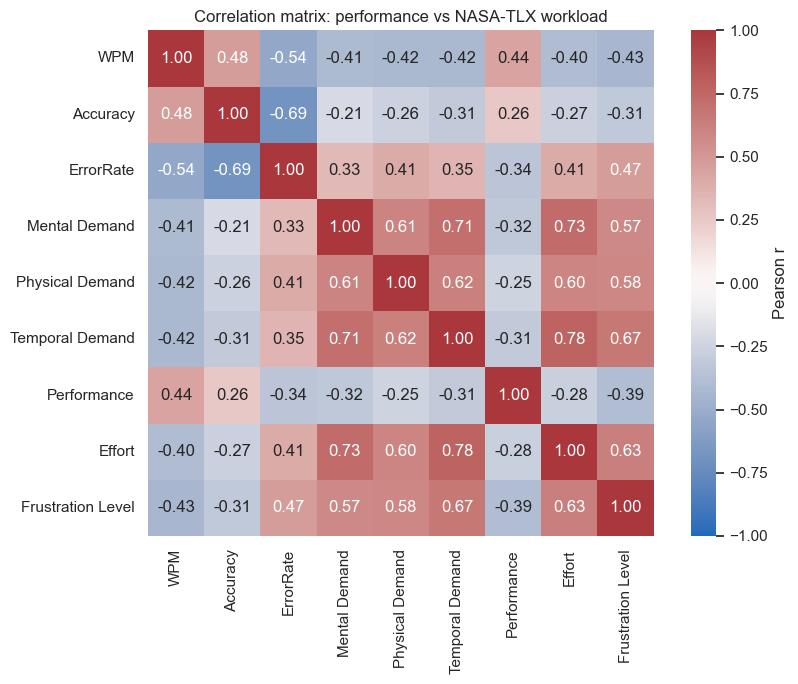

,WPM,Accuracy,ErrorRate,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
WPM,1.00,0.48,-0.54,-0.41,-0.42,-0.42,0.44,-0.40,-0.43
Accuracy,0.48,1.00,-0.69,-0.21,-0.26,-0.31,0.26,-0.27,-0.31
ErrorRate,-0.54,-0.69,1.00,0.33,0.41,0.35,-0.34,0.41,0.47
Mental Demand,-0.41,-0.21,0.33,1.00,0.61,0.71,-0.32,0.73,0.57
Physical Demand,-0.42,-0.26,0.41,0.61,1.00,0.62,-0.25,0.60,0.58
Temporal Demand,-0.42,-0.31,0.35,0.71,0.62,1.00,-0.31,0.78,0.67
Performance,0.44,0.26,-0.34,-0.32,-0.25,-0.31,1.00,-0.28,-0.39
Effort,-0.40,-0.27,0.41,0.73,0.60,0.78,-0.28,1.00,0.63
Frustration Level,-0.43,-0.31,0.47,0.57,0.58,0.67,-0.39,0.63,1.00


In [239]:
task_code_map = {"Text": "A", "Num": "B", "Prog": "C"}
keyboard_code_map = {"60": 1, "100": 2}
dv_metrics = ["WPM", "Accuracy", "ErrorRate"]
dep_columns = dv_metrics + workload_cols

required_perf_cols = {
    f"{task}_{kb}_{metric}"
    for task in task_code_map
    for kb in keyboard_code_map
    for metric in dv_metrics
}
missing_perf_cols = sorted(required_perf_cols - set(typing_test_df.columns))
if missing_perf_cols:
    raise KeyError(
        "Missing expected performance columns: " + ", ".join(missing_perf_cols)
    )

perf_records = []
for _, perf_row in typing_test_df.iterrows():
    for task_label, task_code in task_code_map.items():
        for kb_suffix, kb_code in keyboard_code_map.items():
            record = {
                "Participant Number": perf_row["Participant Number"],
                "Task Type": task_code,
                "Keyboard Type": kb_code,
            }
            for metric in dv_metrics:
                col_name = f"{task_label}_{kb_suffix}_{metric}"
                record[metric] = perf_row[col_name]
            perf_records.append(record)

perf_dep = pd.DataFrame(perf_records)

# Merge NASA-TLX workload ratings onto the reshaped performance metrics
nasa_subset = nasa_tlx_df[
    ["Participant Number", "Keyboard Type", "Task Type"] + workload_cols
].copy()
combined_dep = perf_dep.merge(
    nasa_subset,
    on=["Participant Number", "Keyboard Type", "Task Type"],
    how="inner",
)

if combined_dep.empty:
    raise ValueError("No overlapping observations between typing and NASA-TLX datasets.")

corr_inputs = combined_dep[dep_columns].apply(pd.to_numeric, errors="coerce")
corr_matrix = corr_inputs.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Pearson r"},
)
plt.title("Correlation matrix: performance vs NASA-TLX workload")
plt.tight_layout()

os.makedirs("results/visualizations", exist_ok=True)
corr_matrix_path = "results/visualizations/corr_all_dependent_variables.png"
plt.savefig(corr_matrix_path, dpi=300)
plt.show()

corr_matrix.round(2)


**NASA TLX dimension highlights**
- Mental and Temporal Demand spike on Task B regardless of keyboard, while Physical Demand increases noticeably for KB2 during Task C.
- Effort and Frustration are consistently higher on KB2 for Tasks B/C, hinting that the larger layout may slow precision-heavy work.
- Performance ratings (where higher is better) dip most for KB1 on Task B, suggesting the smaller layout may feel less effective when entering numbers.


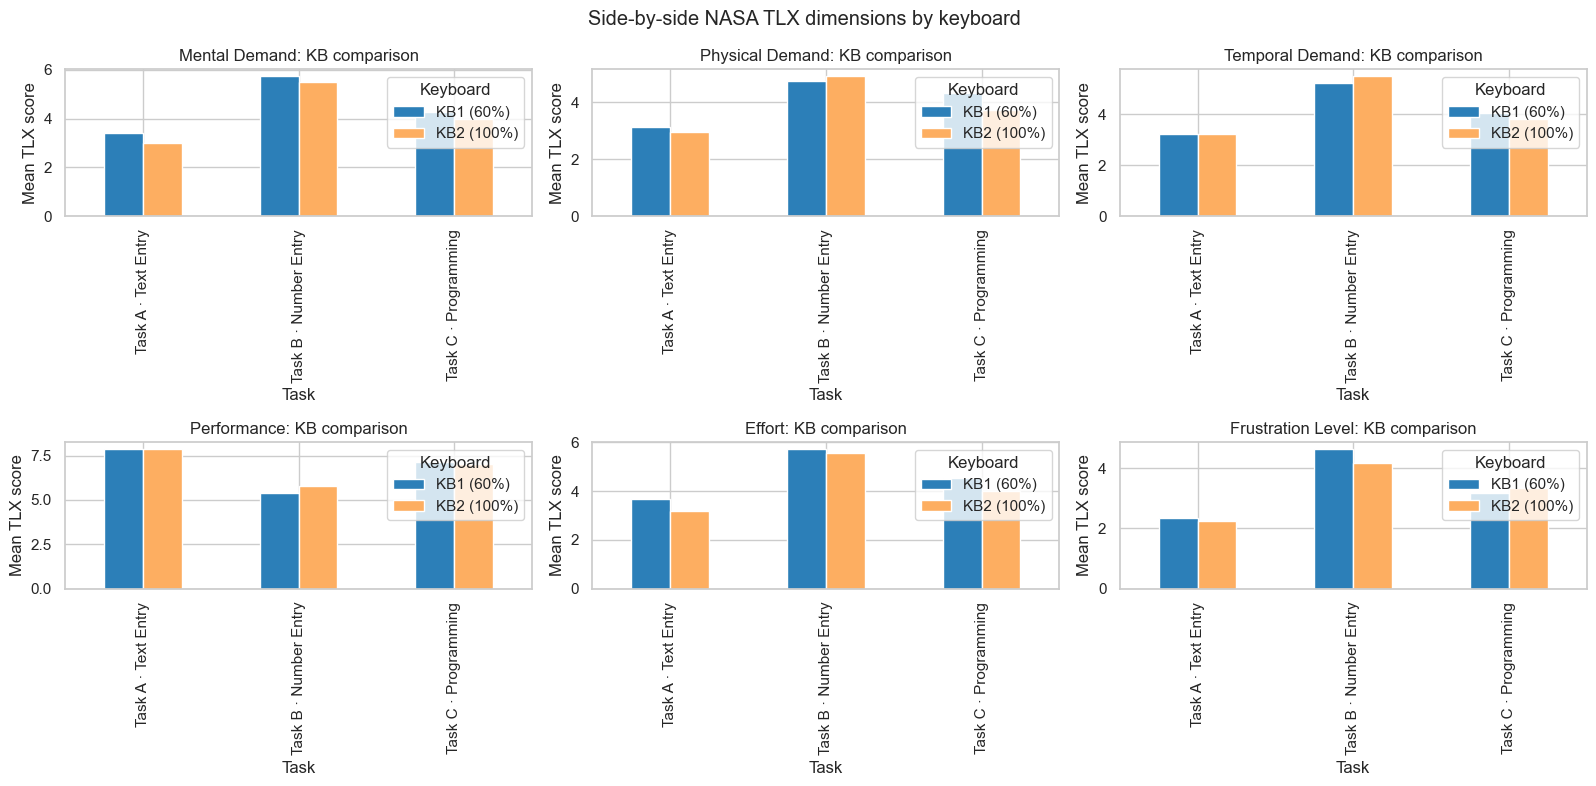

In [240]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = ["#2c7fb8", "#fdae61"]
for ax, (dim, pivot) in zip(axes.ravel(), dimension_pivots.items()):
    pivot.plot(kind="bar", stacked=False, ax=ax, color=colors)
    ax.set_title(f"{dim}: KB comparison")
    ax.set_ylabel("Mean TLX score")
    ax.set_xlabel("Task")
    ax.legend(title="Keyboard", loc="upper right")
plt.suptitle("Side-by-side NASA TLX dimensions by keyboard")
plt.tight_layout()
plt.show()


## Statistical Analysis

###  Preparing dataset

In [241]:
# Prepare NASA TLX with keyboard labels and task codes
keyboard_meta_tlx = {1: "KB1 (60%)", 2: "KB2 (100%)"}

# Task codes are already A/B/C in nasa_tlx_df["Task Type"]. We keep both code and label.
if "Task Type" not in nasa_tlx_df.columns:
    raise KeyError("Expected 'Task Type' column in nasa_tlx_df")

nasa_pref = nasa_tlx_df.copy()
nasa_pref["Keyboard"] = nasa_pref["Keyboard Type"].map(keyboard_meta_tlx)
nasa_pref["TaskCode"] = nasa_pref["Task Type"]  # A, B, C

# Keep one row per participant × keyboard × task, including Original Keyboard and TLX dimensions
nasa_pref = nasa_pref[
    [
        "Participant Number",
        "Original Keyboard",
        "Keyboard",
        "TaskCode",
        "Mental Demand",
        "Physical Demand",
        "Temporal Demand",
        "Performance",
        "Effort",
        "Frustration Level",
    ]
]

# Merge with long-format performance data (perf_long)
if "Participant Number" not in perf_long.columns:
    raise KeyError("Expected 'Participant Number' in perf_long. Make sure the reshaping cell ran.")

perf_tlx = perf_long.merge(
    nasa_pref,
    on=["Participant Number", "Keyboard", "TaskCode"],
    how="inner",
)

# Helper to compute PreferenceMatch based on Original Keyboard and test Keyboard

def compute_preference_match(original_kb: str, test_keyboard: str) -> int:
    """Return 1 if the test keyboard matches the participant's original/preferred keyboard.

    Rules implemented:
    - "Original Keyboard" = "100" AND Keyboard = "KB2 (100%)"
    - "Original Keyboard" = "60" AND Keyboard = "KB1 (60%)"
    - "Original Keyboard" = "Both"  → matches both keyboards
    - "Original Keyboard" contains "100" (e.g., "75 and 100") AND Keyboard = "KB2 (100%)"
    - "Original Keyboard" contains "60" AND Keyboard = "KB1 (60%)"
    - Otherwise → 0
    """
    if pd.isna(original_kb) or pd.isna(test_keyboard):
        return 0

    okb = str(original_kb).strip().lower()
    tkb = str(test_keyboard).strip().lower()

    # Normalize test keyboard to a simple code
    if "60%" in tkb or "kb1" in tkb:
        test_code = "60"
    elif "100%" in tkb or "kb2" in tkb:
        test_code = "100"
    else:
        return 0  # non-60/100 layouts never count as a match

    # Exact matches
    if okb == "both":
        return 1
    if okb == "60" and test_code == "60":
        return 1
    if okb == "100" and test_code == "100":
        return 1

    # Partial-string matches
    if "60" in okb and test_code == "60":
        return 1
    if "100" in okb and test_code == "100":
        return 1

    # All other cases, including TKL, Laptop, 75, etc.
    return 0


perf_tlx["PreferenceMatch"] = perf_tlx.apply(
    lambda row: compute_preference_match(row["Original Keyboard"], row["Keyboard"]), axis=1
)

# Verification table
verification_cols = [
    "Participant Number",
    "Original Keyboard",
    "Keyboard",
    "TaskCode",
    "PreferenceMatch",
]
preference_verification = (
    perf_tlx[verification_cols]
    .drop_duplicates()
    .sort_values(["Participant Number", "Keyboard", "TaskCode"])
    .reset_index(drop=True)
)

# Save updated dataset and verification table
os.makedirs("results/csvs", exist_ok=True)
perf_tlx.to_csv("results/csvs/perf_tlx_with_preference.csv", index=False)
preference_verification.to_csv("results/csvs/preference_verification.csv", index=False)

preference_verification.head()

,Participant Number,Original Keyboard,Keyboard,TaskCode,PreferenceMatch
0,1,TKL,KB1 (60%),A,0
1,1,TKL,KB1 (60%),B,0
2,1,TKL,KB1 (60%),C,0
3,1,TKL,KB2 (100%),A,0
4,1,TKL,KB2 (100%),B,0


### Checking normality of data for all dependent variables

In [242]:
# 1. Data Preparation: Typing Data (Wide to Long format)
# Load typing data if not already loaded
if 'typing_test_df' not in globals():
    typing_test_df = pd.read_csv('typing_test_data.csv')

# Convert from wide to long format
typing_long_rows = []
for _, row in typing_test_df.iterrows():
    participant = row['Participant Number']
    
    # Process each combination: Task (Text, Num, Prog) × Keyboard (60, 100)
    for task_prefix in ['Text', 'Num', 'Prog']:
        for kb_suffix in ['60', '100']:
            # Map keyboard suffix to label
            keyboard_label = 'KB1 (60%)' if kb_suffix == '60' else 'KB2 (100%)'
            
            # Map task prefix to label
            task_map = {
                'Text': 'Task A · Text Entry',
                'Num': 'Task B · Number Entry',
                'Prog': 'Task C · Programming'
            }
            task_label = task_map[task_prefix]
            
            # Extract metrics
            wpm_col = f'{task_prefix}_{kb_suffix}_WPM'
            accuracy_col = f'{task_prefix}_{kb_suffix}_Accuracy'
            error_rate_col = f'{task_prefix}_{kb_suffix}_ErrorRate'
            
            typing_long_rows.append({
                'Participant': participant,
                'Keyboard': keyboard_label,
                'Task': task_label,
                'WPM': row[wpm_col] if wpm_col in row else np.nan,
                'Accuracy': row[accuracy_col] if accuracy_col in row else np.nan,
                'ErrorRate': row[error_rate_col] if error_rate_col in row else np.nan,
            })

typing_long = pd.DataFrame(typing_long_rows)
print(f"Typing data converted to long format: {len(typing_long)} rows")
typing_long.head()


Typing data converted to long format: 198 rows


,Participant,Keyboard,Task,WPM,Accuracy,ErrorRate
0,2.0,KB1 (60%),Task A · Text Entry,89.0,92.4,7.6
1,2.0,KB2 (100%),Task A · Text Entry,96.8,97.1,3.4
2,2.0,KB1 (60%),Task B · Number Entry,26.6,82.4,17.6
3,2.0,KB2 (100%),Task B · Number Entry,30.2,88.2,12.5
4,2.0,KB1 (60%),Task C · Programming,40.2,89.2,10.8


In [243]:
# 2. Data Preparation: NASA TLX Data
# Load NASA data if not already loaded
if 'nasa_tlx_df' not in globals():
    nasa_tlx_df = pd.read_csv('nasa_tlx.csv')

# Calculate Raw TLX (mean of 6 subscales)
workload_cols = [
    'Mental Demand',
    'Physical Demand',
    'Temporal Demand',
    'Performance',
    'Effort',
    'Frustration Level'
]

nasa_tlx_df['Raw_TLX'] = nasa_tlx_df[workload_cols].mean(axis=1)

# Map Keyboard Type (1 vs 2) and Task Type (A vs B vs C) to labels
keyboard_map = {1: 'KB1 (60%)', 2: 'KB2 (100%)'}
task_map = {'A': 'Task A · Text Entry', 'B': 'Task B · Number Entry', 'C': 'Task C · Programming'}

nasa_tlx_df['Keyboard'] = nasa_tlx_df['Keyboard Type'].map(keyboard_map)
nasa_tlx_df['Task'] = nasa_tlx_df['Task Type'].map(task_map)

print(f"NASA TLX data prepared: {len(nasa_tlx_df)} rows")
print(f"Raw TLX range: {nasa_tlx_df['Raw_TLX'].min():.2f} - {nasa_tlx_df['Raw_TLX'].max():.2f}")
nasa_tlx_df[['Participant Number', 'Keyboard', 'Task', 'Raw_TLX']].head()


NASA TLX data prepared: 198 rows
Raw TLX range: 1.83 - 8.50


,Participant Number,Keyboard,Task,Raw_TLX
0,15,KB1 (60%),Task A · Text Entry,2.500000
1,15,KB1 (60%),Task B · Number Entry,5.166667
2,15,KB1 (60%),Task C · Programming,3.500000
3,15,KB2 (100%),Task A · Text Entry,2.000000
4,15,KB2 (100%),Task B · Number Entry,5.166667


In [244]:
# 3. Run Shapiro-Wilk Tests
# Define dependent variables and their data sources
dependent_variables = {
    'WPM': typing_long,
    'Accuracy': typing_long,
    'ErrorRate': typing_long,
    'Raw_TLX': nasa_tlx_df
}

# Define experimental conditions
keyboards = ['KB1 (60%)', 'KB2 (100%)']
tasks = ['Task A · Text Entry', 'Task B · Number Entry', 'Task C · Programming']

# Container for results
normality_results = []

# Loop through each dependent variable
for var_name, data_df in dependent_variables.items():
    # Loop through each experimental condition
    for keyboard in keyboards:
        for task in tasks:
            # Filter data for this condition
            condition_data = data_df[
                (data_df['Keyboard'] == keyboard) & 
                (data_df['Task'] == task)
            ][var_name].dropna()
            
            # Skip if insufficient data (Shapiro-Wilk requires at least 3 observations)
            if len(condition_data) < 3:
                normality_results.append({
                    'Variable': var_name,
                    'Keyboard': keyboard,
                    'Task': task,
                    'N': len(condition_data),
                    'W-Statistic': np.nan,
                    'p-value': np.nan,
                    'Normality': 'Insufficient data'
                })
                continue
            
            # Run Shapiro-Wilk test
            try:
                w_stat, p_value = shapiro(condition_data)
                
                # Determine normality status
                normality_status = 'Normal' if p_value > 0.05 else 'Violation'
                
                normality_results.append({
                    'Variable': var_name,
                    'Keyboard': keyboard,
                    'Task': task,
                    'N': len(condition_data),
                    'W-Statistic': round(w_stat, 3),
                    'p-value': round(p_value, 3),
                    'Normality': normality_status
                })
            except Exception as e:
                normality_results.append({
                    'Variable': var_name,
                    'Keyboard': keyboard,
                    'Task': task,
                    'N': len(condition_data),
                    'W-Statistic': np.nan,
                    'p-value': np.nan,
                    'Normality': f'Error: {str(e)}'
                })

print(f"Completed Shapiro-Wilk tests for {len(normality_results)} conditions")


Completed Shapiro-Wilk tests for 24 conditions


In [245]:
# 4. Create consolidated results DataFrame
normality_df = pd.DataFrame(normality_results)

# Group by Variable for easier reading
normality_df = normality_df.sort_values(['Variable', 'Keyboard', 'Task']).reset_index(drop=True)

print("=" * 80)
print("Shapiro-Wilk Test Results for Normality Assumption")
print("=" * 80)
print()

# Print grouped by variable
for var in normality_df['Variable'].unique():
    var_subset = normality_df[normality_df['Variable'] == var]
    print(f"\n{var}:")
    print("-" * 80)
    display(var_subset[['Keyboard', 'Task', 'N', 'W-Statistic', 'p-value', 'Normality']])


Shapiro-Wilk Test Results for Normality Assumption


Accuracy:
--------------------------------------------------------------------------------


,Keyboard,Task,N,W-Statistic,p-value,Normality
0,KB1 (60%),Task A · Text Entry,33,0.892,0.003,Violation
1,KB1 (60%),Task B · Number Entry,33,0.615,0.000,Violation
2,KB1 (60%),Task C · Programming,33,0.412,0.000,Violation
3,KB2 (100%),Task A · Text Entry,33,0.949,0.121,Normal
4,KB2 (100%),Task B · Number Entry,33,0.963,0.315,Normal
5,KB2 (100%),Task C · Programming,33,0.791,0.000,Violation



ErrorRate:
--------------------------------------------------------------------------------


,Keyboard,Task,N,W-Statistic,p-value,Normality
6,KB1 (60%),Task A · Text Entry,33,0.853,0.000,Violation
7,KB1 (60%),Task B · Number Entry,33,0.889,0.003,Violation
8,KB1 (60%),Task C · Programming,33,0.848,0.000,Violation
9,KB2 (100%),Task A · Text Entry,33,0.929,0.033,Violation
10,KB2 (100%),Task B · Number Entry,33,0.942,0.077,Normal
11,KB2 (100%),Task C · Programming,33,0.981,0.811,Normal



Raw_TLX:
--------------------------------------------------------------------------------


,Keyboard,Task,N,W-Statistic,p-value,Normality
12,KB1 (60%),Task A · Text Entry,33,0.902,0.006,Violation
13,KB1 (60%),Task B · Number Entry,33,0.948,0.113,Normal
14,KB1 (60%),Task C · Programming,33,0.979,0.750,Normal
15,KB2 (100%),Task A · Text Entry,33,0.937,0.057,Normal
16,KB2 (100%),Task B · Number Entry,33,0.973,0.571,Normal
17,KB2 (100%),Task C · Programming,33,0.951,0.138,Normal



WPM:
--------------------------------------------------------------------------------


,Keyboard,Task,N,W-Statistic,p-value,Normality
18,KB1 (60%),Task A · Text Entry,33,0.979,0.758,Normal
19,KB1 (60%),Task B · Number Entry,33,0.987,0.958,Normal
20,KB1 (60%),Task C · Programming,33,0.966,0.381,Normal
21,KB2 (100%),Task A · Text Entry,33,0.964,0.324,Normal
22,KB2 (100%),Task B · Number Entry,33,0.965,0.363,Normal
23,KB2 (100%),Task C · Programming,33,0.966,0.377,Normal


In [246]:
# Display full results table
print("=" * 80)
print("Full Results Table:")
print("=" * 80)
display(normality_df)


Full Results Table:


,Variable,Keyboard,Task,N,W-Statistic,p-value,Normality
0,Accuracy,KB1 (60%),Task A · Text Entry,33,0.892,0.003,Violation
1,Accuracy,KB1 (60%),Task B · Number Entry,33,0.615,0.000,Violation
2,Accuracy,KB1 (60%),Task C · Programming,33,0.412,0.000,Violation
3,Accuracy,KB2 (100%),Task A · Text Entry,33,0.949,0.121,Normal
4,Accuracy,KB2 (100%),Task B · Number Entry,33,0.963,0.315,Normal
5,Accuracy,KB2 (100%),Task C · Programming,33,0.791,0.000,Violation
6,ErrorRate,KB1 (60%),Task A · Text Entry,33,0.853,0.000,Violation
7,ErrorRate,KB1 (60%),Task B · Number Entry,33,0.889,0.003,Violation
8,ErrorRate,KB1 (60%),Task C · Programming,33,0.848,0.000,Violation
9,ErrorRate,KB2 (100%),Task A · Text Entry,33,0.929,0.033,Violation


In [247]:
# Save results to CSV
os.makedirs('results/csvs', exist_ok=True)
normality_df.to_csv('results/csvs/normality_shapiro_wilk_results.csv', index=False)
print(f"✓ Results saved to: results/csvs/normality_shapiro_wilk_results.csv")


✓ Results saved to: results/csvs/normality_shapiro_wilk_results.csv


### Setup of two-way repeated measures ANOVA

Repeated-measures ANOVA readiness verification

In [248]:
from itertools import product
from pandas.api.types import CategoricalDtype

try:
    df = perf_long.copy()
except NameError as err:
    raise NameError(
        "perf_long is not defined earlier in the notebook; please load/reshape the data before running checks"
    ) from err

participant_col = "Participant_Number"
if participant_col not in df.columns:
    df = df.rename(columns={"Participant Number": participant_col})

factor_cols = [participant_col, "Keyboard", "Task"]
for col in factor_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Factor dtype overview:")
factor_dtype_report = pd.Series({col: str(df[col].dtype) for col in factor_cols})
print(factor_dtype_report)

non_categorical = [
    col for col in factor_cols
    if not isinstance(df[col].dtype, CategoricalDtype)
]
if non_categorical:
    print(f"Non-categorical factors detected: {non_categorical}")
else:
    print("All factor columns are categorical.")

condition_counts = (
    df.groupby(factor_cols, dropna=False, observed=False)
    .size()
    .reset_index(name="row_count")
)
duplicate_condition_rows = condition_counts[condition_counts["row_count"] > 1]
if duplicate_condition_rows.empty:
    print("No duplicated participant × keyboard × task rows detected.")
else:
    print("Duplicated participant × keyboard × task rows detected:")
    display(duplicate_condition_rows.sort_values(factor_cols).reset_index(drop=True))

participants = df[participant_col].unique()
keyboards = df["Keyboard"].unique()
tasks = df["Task"].unique()
expected_conditions = len(keyboards) * len(tasks)
print(f"Unique participants: {len(participants)} | keyboards: {len(keyboards)} | tasks: {len(tasks)}")
print(f"Expected conditions per participant: {expected_conditions}")

missing_records = []
for participant in participants:
    participant_slice = condition_counts[condition_counts[participant_col] == participant]
    for kb, task in product(keyboards, tasks):
        mask = (participant_slice["Keyboard"] == kb) & (participant_slice["Task"] == task)
        if not mask.any():
            missing_records.append({
                participant_col: participant,
                "Keyboard": kb,
                "Task": task,
            })

if missing_records:
    missing_cells = pd.DataFrame(missing_records)
    print(
        f"Missing cells detected: {len(missing_cells)} participant × keyboard × task combinations are absent."
    )
    display(
        missing_cells.sort_values([participant_col, "Keyboard", "Task"]).reset_index(drop=True)
    )
else:
    print("All participants have measurements for every keyboard × task combination.")

imbalanced_participants = (
    condition_counts.groupby(participant_col, observed=False).size().reset_index(name="observed_conditions")
)
imbalanced_participants = imbalanced_participants[
    imbalanced_participants["observed_conditions"] != expected_conditions
]
if imbalanced_participants.empty:
    print("Balanced design confirmed: each participant has one row per condition.")
else:
    print("Imbalanced participants detected (unexpected number of conditions):")
    display(imbalanced_participants)

Factor dtype overview:
Participant_Number    category
Keyboard              category
Task                  category
dtype: object
All factor columns are categorical.
No duplicated participant × keyboard × task rows detected.
Unique participants: 33 | keyboards: 2 | tasks: 3
Expected conditions per participant: 6
All participants have measurements for every keyboard × task combination.
Balanced design confirmed: each participant has one row per condition.


Helper function for running two way repeated measures ANOVA

In [249]:
def run_two_way_rm_anova(
    data,
    depvar,
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
    coerce_numeric=True,
):
    """Run a two-way repeated-measures ANOVA using pingouin and
    construct a publication-ready source table with explicit error rows.

    Returns
    -------
    dict
        {
            "rm_anova": pingouin rm_anova results (detailed table),
            "source_table": tidy source table with columns
                ["Source", "SS", "ddof1", "MS", "F", "p-unc", "ng2"].
        }
    """
    required_cols = [depvar, subject_col, *within_factors]
    missing = [col for col in required_cols if col not in data.columns]
    if missing:
        raise KeyError(f"Columns missing from dataframe: {missing}")

    anova_df = data.copy()
    if coerce_numeric:
        anova_df[depvar] = pd.to_numeric(anova_df[depvar], errors="coerce")

    # Ensure factors are categorical
    for col in [subject_col, *within_factors]:
        if col in anova_df.columns and not isinstance(anova_df[col].dtype, CategoricalDtype):
            anova_df[col] = anova_df[col].astype("category")

    # Pingouin two-way repeated-measures ANOVA
    aov = pg.rm_anova(
        dv=depvar,
        within=list(within_factors),
        subject=subject_col,
        data=anova_df,
        detailed=True,
        effsize="np2",
    )

    # Basic design information for deriving error degrees of freedom
    n_subjects = anova_df[subject_col].nunique()
    level_counts = {f: anova_df[f].nunique() for f in within_factors}

    # Build a custom source table with explicit error rows per effect
    effect_order = ["Keyboard", "Task", "Keyboard * Task"]
    rows = []

    for effect in effect_order:
        effect_row = aov.loc[aov["Source"] == effect]
        if effect_row.empty:
            continue
        effect_row = effect_row.iloc[0]

        ss_effect = float(effect_row["SS"])
        # Derive numerator and denominator degrees of freedom from the balanced
        # repeated-measures design rather than relying on pingouin's column names.
        if effect == "Keyboard":
            df1 = float(level_counts.get("Keyboard", np.nan) - 1)
            df2 = float((n_subjects - 1) * df1) if np.isfinite(df1) else np.nan
        elif effect == "Task":
            df1 = float(level_counts.get("Task", np.nan) - 1)
            df2 = float((n_subjects - 1) * df1) if np.isfinite(df1) else np.nan
        elif effect == "Keyboard * Task":
            a_levels = level_counts.get("Keyboard", np.nan)
            b_levels = level_counts.get("Task", np.nan)
            if np.isfinite(a_levels) and np.isfinite(b_levels):
                df1 = float((a_levels - 1) * (b_levels - 1))
                df2 = float((n_subjects - 1) * df1)
            else:
                df1 = np.nan
                df2 = np.nan
        else:
            # Fallback: use DF from pingouin if present, otherwise NaN
            df1 = float(effect_row.get("DF", np.nan))
            df2 = np.nan

        ms_effect = float(effect_row["MS"])
        f_val = float(effect_row["F"])
        p_val = float(effect_row["p-unc"])

        # Derive the corresponding error term from F = MS_effect / MS_error
        if np.isfinite(f_val) and f_val != 0:
            ms_error = ms_effect / f_val
            ss_error = ms_error * df2
        else:
            ms_error = np.nan
            ss_error = np.nan

        # Partial eta-squared based on SS_effect and its error term
        if np.isfinite(ss_effect) and np.isfinite(ss_error) and (ss_effect + ss_error) != 0:
            ng2 = ss_effect / (ss_effect + ss_error)
        else:
            ng2 = np.nan

        rows.append(
            {
                "Source": effect,
                "SS": ss_effect,
                "ddof1": df1,
                "MS": ms_effect,
                "F": f_val,
                "p-unc": p_val,
                "ng2": ng2,
            }
        )
        rows.append(
            {
                "Source": f"Error({effect})",
                "SS": ss_error,
                "ddof1": df2,
                "MS": ms_error,
                "F": np.nan,
                "p-unc": np.nan,
                "ng2": np.nan,
            }
        )

    source_table = pd.DataFrame(rows, columns=["Source", "SS", "ddof1", "MS", "F", "p-unc", "ng2"])

    return {"rm_anova": aov, "source_table": source_table}

### $H_{0}$ - Words per Minute (WPM)
- There is no significant difference in a user's words per minute (WPM) between a 60\% keyboard and a 100\% keyboard.
- Conduct two-way repeated measures ANOVA

In [250]:
# Two-way repeated-measures ANOVA (pingouin): WPM ~ Keyboard * Task
wpm_result = run_two_way_rm_anova(
    data=df,
    depvar="WPM",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)
wpm_source_table = wpm_result["source_table"]
wpm_source_table


/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,MS,F,p-unc,ng2
0,Keyboard,0.827475,1.0,0.827475,0.015169,9.027481e-01,0.000474
1,Error(Keyboard),1745.589192,32.0,54.549662,NaN,NaN,NaN
2,Task,59952.361919,2.0,29976.180960,244.644081,1.055152e-30,0.884328
3,Error(Task),7841.904747,64.0,122.529762,NaN,NaN,NaN
4,Keyboard * Task,34.824949,2.0,17.412475,0.388380,6.797417e-01,0.011991
5,Error(Keyboard * Task),2869.348384,64.0,44.833568,NaN,NaN,NaN


In [251]:
# Prepare data for professional visualizations (H0-H3)
# Create simplified versions with "60%" and "100%" keyboard labels and simplified task labels

# For typing data: use perf_long (same as used in ANOVA analyses)
plot_typing_data = perf_long.copy()
plot_typing_data['Keyboard_Simple'] = plot_typing_data['Keyboard'].map({
    'KB1 (60%)': '60%',
    'KB2 (100%)': '100%'
})
plot_typing_data['Task_Simple'] = plot_typing_data['Task'].map({
    'Task A · Text Entry': 'Text',
    'Task B · Number Entry': 'Num',
    'Task C · Programming': 'Prog'
})

# For NASA TLX data: ensure Raw_TLX is calculated and simplify labels
if 'Raw_TLX' not in nasa_tlx_df.columns:
    workload_cols = ['Mental Demand', 'Physical Demand', 'Temporal Demand', 
                     'Performance', 'Effort', 'Frustration Level']
    nasa_tlx_df['Raw_TLX'] = nasa_tlx_df[workload_cols].mean(axis=1)

plot_nasa_data = nasa_tlx_df.copy()
plot_nasa_data['Keyboard_Simple'] = plot_nasa_data['Keyboard Type'].map({1: '60%', 2: '100%'})
plot_nasa_data['Task_Simple'] = plot_nasa_data['Task Type'].map({'A': 'Text', 'B': 'Num', 'C': 'Prog'})

print("Data prepared for visualizations")
print(f"Typing data: {len(plot_typing_data)} rows")
print(f"NASA TLX data: {len(plot_nasa_data)} rows")


Data prepared for visualizations
Typing data: 198 rows
NASA TLX data: 198 rows


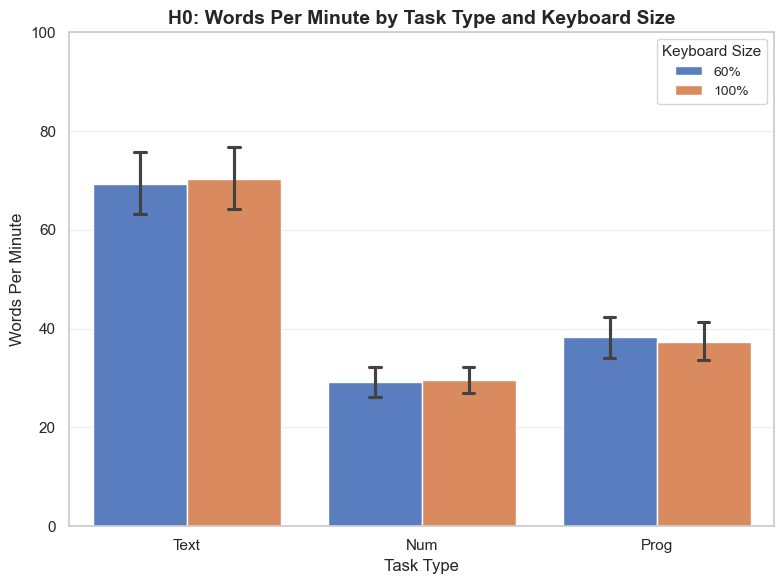

✓ Saved: results/visualizations/results_wpm.png


In [252]:
# H0 Visualization: WPM by Task Type and Keyboard Size
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=plot_typing_data,
    x='Task_Simple',
    y='WPM',
    hue='Keyboard_Simple',
    palette='muted',
    errorbar=('ci', 95),
    capsize=0.1
)
plt.grid(axis='y', alpha=0.3)
plt.xlabel('Task Type', fontsize=12)
plt.ylabel('Words Per Minute', fontsize=12)
plt.title('H0: Words Per Minute by Task Type and Keyboard Size', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.legend(title='Keyboard Size', title_fontsize=11, fontsize=10, loc='upper right')
plt.tight_layout()

# Save high-resolution figure
os.makedirs('results/visualizations', exist_ok=True)
plt.savefig('results/visualizations/results_wpm.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: results/visualizations/results_wpm.png")


Interpretation of results above:

##### 1. Main Effect of Keyboard — NOT significant

F(1, 32) = 0.0152, p = .9027 → No keyboard effect

This means:

Participants did not type faster on one keyboard versus the other.

WPM performance on the 60% keyboard and the 100% keyboard is statistically indistinguishable.

A p-value this large (0.90) means the effect is extremely unlikely to be meaningful.

##### 2. Main Effect of Task — VERY significant

F(2, 64) = 244.644, p < .0001 → Strong task effect

This means:

Task type massively affects typing speed.

Participants typed at very different speeds depending on whether the task was:

Text typing (Task A)

Number entry (Task B)

Programming-like entry (Task C)

Still need post-hoc tests (pairwise comparison of A vs B vs C) to determine exactly which tasks differ — but given F ≈ 245, the differences are almost certainly large and clear.

##### 3. Keyboard × Task Interaction — NOT significant

F(2, 64) = 0.3884, p = .6797 → No interaction

This means:

The effect of Task does not depend on the keyboard type.

The difference between Tasks A, B, and C is consistent regardless of whether participants used the 60% or 100% keyboard.

Basically... switching keyboards doesn’t change which tasks are easier or harder.


### $H_{1}$ - Accuracy
- There is no significant difference in a user’s accuracy between a 60% keyboard and a 100% keyboard.
- Conduct two-way repeated measures ANOVA

In [253]:
# Two-way repeated-measures ANOVA (pingouin): Accuracy ~ Keyboard * Task
accuracy_result = run_two_way_rm_anova(
    data=df,
    depvar="Accuracy",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)
accuracy_source_table = accuracy_result["source_table"]
accuracy_source_table


/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,MS,F,p-unc,ng2
0,Keyboard,56.106869,1.0,56.106869,0.813050,0.373957,0.024778
1,Error(Keyboard),2208.253131,32.0,69.007910,NaN,NaN,NaN
2,Task,1300.734040,2.0,650.367020,11.654749,0.000048,0.266976
3,Error(Task),3571.375960,64.0,55.802749,NaN,NaN,NaN
4,Keyboard * Task,1.616465,2.0,0.808232,0.016132,0.984002,0.000504
5,Error(Keyboard * Task),3206.573535,64.0,50.102711,NaN,NaN,NaN


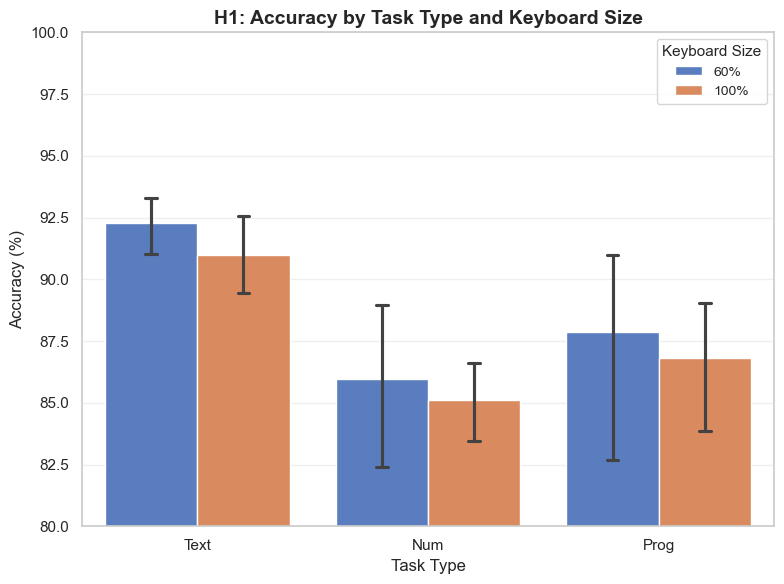

✓ Saved: results/visualizations/results_accuracy.png


In [254]:
# H1 Visualization: Accuracy by Task Type and Keyboard Size
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=plot_typing_data,
    x='Task_Simple',
    y='Accuracy',
    hue='Keyboard_Simple',
    palette='muted',
    errorbar=('ci', 95),
    capsize=0.1
)
plt.grid(axis='y', alpha=0.3)
plt.xlabel('Task Type', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('H1: Accuracy by Task Type and Keyboard Size', fontsize=14, fontweight='bold')
plt.ylim(80, 100)
plt.legend(title='Keyboard Size', title_fontsize=11, fontsize=10, loc='upper right')
plt.tight_layout()

# Save high-resolution figure
os.makedirs('results/visualizations', exist_ok=True)
plt.savefig('results/visualizations/results_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: results/visualizations/results_accuracy.png")


### $H_{2}$ - Error Rate
- There is no significant difference in a user’s error rate between a 60% keyboard and a 100% keyboard.
- Conduct two-way repeated measures ANOVA

In [255]:
# Two-way repeated-measures ANOVA (pingouin): ErrorRate ~ Keyboard * Task
error_rate_result = run_two_way_rm_anova(
    data=df,
    depvar="ErrorRate",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)
error_rate_source_table = error_rate_result["source_table"]
error_rate_source_table

/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,MS,F,p-unc,ng2
0,Keyboard,42.654596,1.0,42.654596,2.705363,1.098010e-01,0.077952
1,Error(Keyboard),504.533737,32.0,15.766679,NaN,NaN,NaN
2,Task,1027.517677,2.0,513.758838,35.461106,4.316072e-11,0.525653
3,Error(Task),927.228990,64.0,14.487953,NaN,NaN,NaN
4,Keyboard * Task,3.988586,2.0,1.994293,0.173691,8.409515e-01,0.005399
5,Error(Keyboard * Task),734.838081,64.0,11.481845,NaN,NaN,NaN


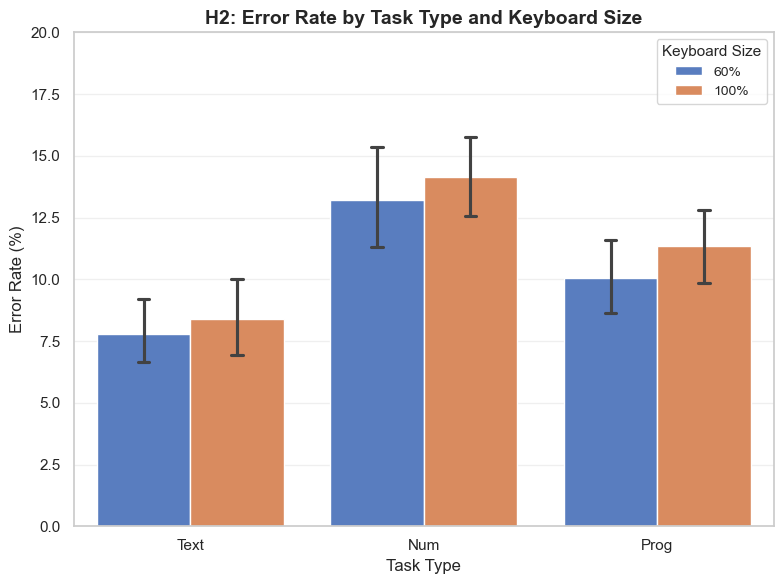

✓ Saved: results/visualizations/results_errorrate.png


In [256]:
# H2 Visualization: Error Rate by Task Type and Keyboard Size
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=plot_typing_data,
    x='Task_Simple',
    y='ErrorRate',
    hue='Keyboard_Simple',
    palette='muted',
    errorbar=('ci', 95),
    capsize=0.1
)
plt.grid(axis='y', alpha=0.3)
plt.xlabel('Task Type', fontsize=12)
plt.ylabel('Error Rate (%)', fontsize=12)
plt.title('H2: Error Rate by Task Type and Keyboard Size', fontsize=14, fontweight='bold')
plt.ylim(0, 20)
plt.legend(title='Keyboard Size', title_fontsize=11, fontsize=10, loc='upper right')
plt.tight_layout()

# Save high-resolution figure
os.makedirs('results/visualizations', exist_ok=True)
plt.savefig('results/visualizations/results_errorrate.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: results/visualizations/results_errorrate.png")


### $H_{3}$ - Perceived Workload (NASA TLX dimensions)
- There is no significant difference in a user’s perceived workload between a 60% keyboard and a 100% keyboard.
- Conduct two way repeated measures ANOVA

In [257]:
nasa_rm_df = nasa_aug.rename(columns={"Participant Number": "Participant_Number"}).copy()

# Compute Raw TLX score as the mean of the six NASA-TLX subscales
# (Mental, Physical, Temporal, Performance, Effort, Frustration).
nasa_rm_df["Raw_TLX"] = nasa_rm_df[workload_cols].mean(axis=1)

# Container for storing pingouin-based RM ANOVA results
nasa_rm_results = {}

#### Raw TLX (primary workload outcome)

In [258]:
# Two-way repeated-measures ANOVA (pingouin) on overall Raw TLX
nasa_rm_results["Raw_TLX"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Raw_TLX",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)
raw_tlx_source_table = nasa_rm_results["Raw_TLX"]["source_table"]
raw_tlx_source_table

/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,MS,F,p-unc,ng2
0,Keyboard,1.266134,1.0,1.266134,1.836426,1.848599e-01,0.054274
1,Error(Keyboard),22.062570,32.0,0.689455,NaN,NaN,NaN
2,Task,65.035634,2.0,32.517817,47.456917,2.293953e-13,0.597266
3,Error(Task),43.853255,64.0,0.685207,NaN,NaN,NaN
4,Keyboard * Task,0.591190,2.0,0.295595,0.737559,4.823005e-01,0.022529
5,Error(Keyboard * Task),25.649551,64.0,0.400774,NaN,NaN,NaN


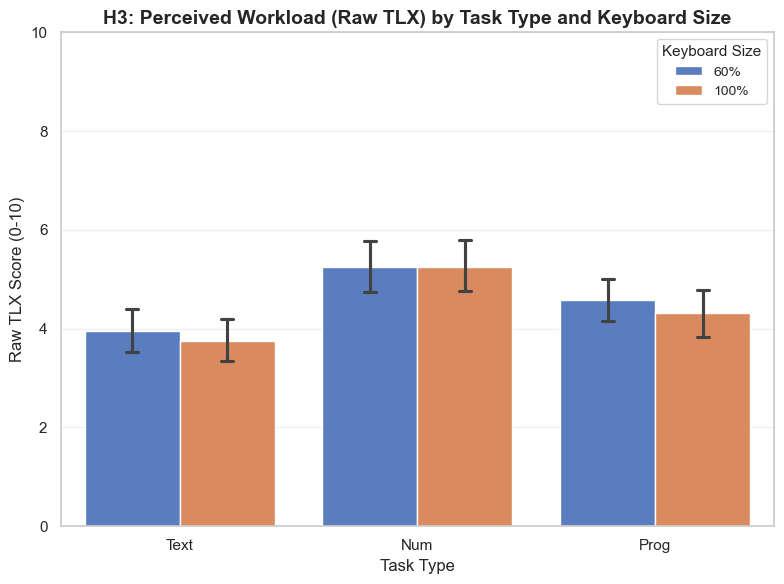

✓ Saved: results/visualizations/results_workload.png


In [259]:
# H3 Visualization: Raw TLX Score by Task Type and Keyboard Size
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=plot_nasa_data,
    x='Task_Simple',
    y='Raw_TLX',
    hue='Keyboard_Simple',
    palette='muted',
    errorbar=('ci', 95),
    capsize=0.1
)
plt.grid(axis='y', alpha=0.3)
plt.xlabel('Task Type', fontsize=12)
plt.ylabel('Raw TLX Score (0-10)', fontsize=12)
plt.title('H3: Perceived Workload (Raw TLX) by Task Type and Keyboard Size', fontsize=14, fontweight='bold')
plt.ylim(0, 10)
plt.legend(title='Keyboard Size', title_fontsize=11, fontsize=10, loc='upper right')
plt.tight_layout()

# Save high-resolution figure
os.makedirs('results/visualizations', exist_ok=True)
plt.savefig('results/visualizations/results_workload.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: results/visualizations/results_workload.png")


In [260]:
# NOTE: Follow-up ANOVAs on individual NASA-TLX subscales (e.g., Mental Demand)
# should ONLY be conducted if the main Raw TLX ANOVA shows a significant effect.
raw_tlx_pvals = (
    nasa_rm_results["Raw_TLX"]["rm_anova"]
    .set_index("Source")
    .loc[["Keyboard", "Task", "Keyboard * Task"], "p-unc"]
)
if (raw_tlx_pvals < 0.05).any():
    # If and only if this condition is met, additional subscale-level RM ANOVAs
    # MAY be run in a separate exploratory step. We intentionally do NOT
    # execute those subscale ANOVAs automatically in this notebook.
    pass

#### Subscale follow-ups (not run automatically)

Any further RM ANOVAs on individual NASA-TLX subscales (Mental, Physical, Temporal,
Performance, Effort, Frustration) should be treated as follow-up analyses and only
considered if the overall Raw TLX ANOVA is significant (see code cell above).


In [261]:
# Placeholder: subscale-level RM ANOVAs (e.g., Mental Demand) are intentionally
# NOT executed here. See the conditional logic in the Raw TLX cell above for when
# such analyses would be appropriate in a separate follow-up step.

#### Temporal Demand


In [262]:
nasa_rm_results["Temporal Demand"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Temporal Demand",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


#### Performance


In [263]:
nasa_rm_results["Performance"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Performance",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


#### Effort


In [264]:
nasa_rm_results["Effort"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Effort",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


#### Frustration Level


In [265]:
nasa_rm_results["Frustration Level"] = run_two_way_rm_anova(
    data=nasa_rm_df,
    depvar="Frustration Level",
    subject_col="Participant_Number",
    within_factors=("Keyboard", "Task"),
    alpha=0.05,
)

/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


### $H_{4}$ - Keyboard-Task Combo versus Typing Performance
- There is no significant difference in the suitability of a 60% keyboard versus a 100% keyboard for specific kinds of typing tasks.
- Conduct MIxed Mdoel Effects Analysis
- TODO: Figure out why?
- Conduct Post-Hoc analyses apparently:
  - Conclusion for your Thesis: "Post-hoc analyses revealed significant differences in difficulty between tasks (Task B being the hardest), but no significant differences were found between keyboard sizes for any specific task."

In [266]:
numeric_cols = perf_metrics
perf_long[numeric_cols] = perf_long[numeric_cols].apply(pd.to_numeric, errors="coerce")

perf_summary = (
    perf_long.groupby(["Keyboard", "Task"])[["WPM", "Accuracy", "ErrorRate", "TotalTime"]]
    .agg(["mean", "std"])
    .round(2)
)
perf_summary


WPM        Accuracy        ErrorRate  \
                                   mean    std     mean    std      mean   
Keyboard   Task                                                            
KB1 (60%)  Task A · Text Entry    69.28  18.64    92.28   3.52      7.80   
           Task B · Number Entry  29.19   8.99    85.94  10.08     13.22   
           Task C · Programming   38.38  12.65    87.87  13.73     10.05   
KB2 (100%) Task A · Text Entry    70.31  19.48    90.99   4.69      8.39   
           Task B · Number Entry  29.54   7.74    85.10   4.68     14.12   
           Task C · Programming   37.38  11.93    86.80   7.95     11.34   

                                       TotalTime         
                                   std      mean    std  
Keyboard   Task                                          
KB1 (60%)  Task A · Text Entry    3.96     60.86  19.69  
           Task B · Number Entry  6.09    111.66  12.78  
           Task C · Programming   4.60     95.11  21.93  
KB2 (100%) Task A · Text Entry    4.53     60.22  20.86  
           Task B · Number Entry  4.76    112.30  12.55  
           Task C · Programming   4.31     97.96  20.36

Difference in Mean WPM for KB1 versus KB2. 

In [267]:
# TODO: Add more analysis here.
wpm_pivot = perf_long.groupby(["Task", "Keyboard"])['WPM'].mean().unstack()
wpm_pivot['Difference from KB2-KB1'] = wpm_pivot['KB2 (100%)'] - wpm_pivot['KB1 (60%)']
wpm_pivot.round(2)

Keyboard,KB1 (60%),KB2 (100%),Difference from KB2-KB1
Task,,,
Task A · Text Entry,69.28,70.31,1.03
Task B · Number Entry,29.19,29.54,0.35
Task C · Programming,38.38,37.38,-0.99


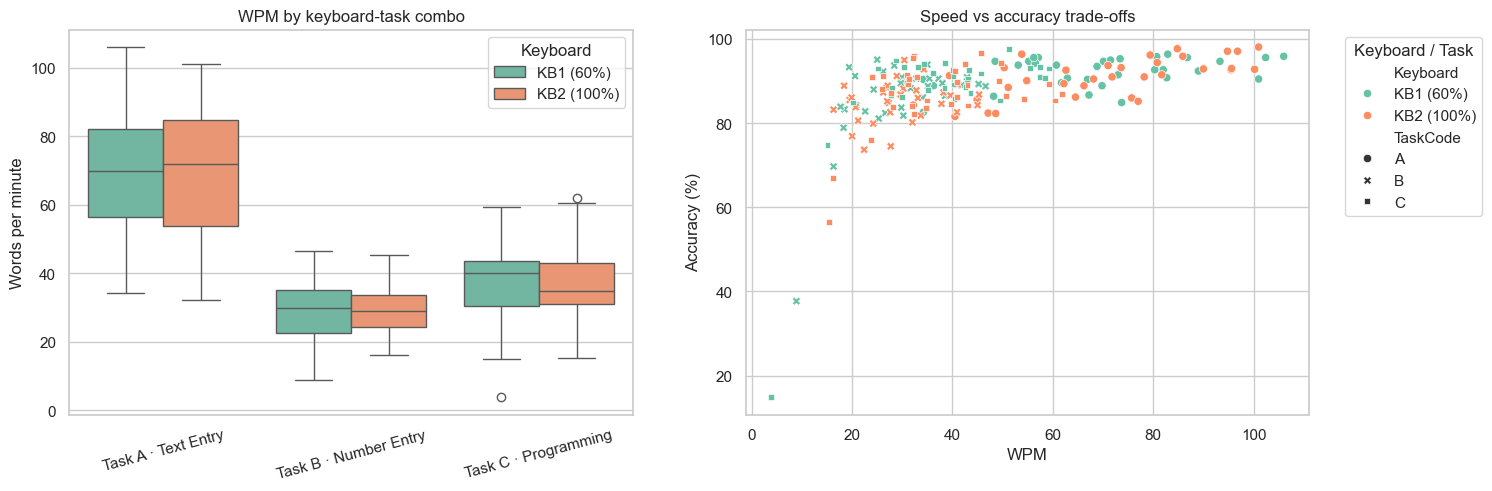

In [268]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=perf_long,
    x="Task",
    y="WPM",
    hue="Keyboard",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("WPM by keyboard-task combo")
axes[0].set_xlabel("")
axes[0].set_ylabel("Words per minute")
axes[0].tick_params(axis='x', rotation=15)

sns.scatterplot(
    data=perf_long,
    x="WPM",
    y="Accuracy",
    hue="Keyboard",
    style="TaskCode",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Speed vs accuracy trade-offs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(title="Keyboard / Task", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

#### Keyboard × Task Mixed-Effects Analysis

To directly evaluate whether the 100% keyboard (KB2) outperforms the 60% keyboard (KB1) for specific tasks—especially Task B (number entry)—we fit linear mixed-effects models with Keyboard and Task as fixed factors and participant as a random intercept. The following cells run those models, export tidy CSV tables, and recreate the key summaries inline.


In [269]:
from statsmodels.stats.anova import anova_lm

keyboard_task_dvs = ["WPM", "Accuracy", "ErrorRate", "TotalTime"]
keyboard_task_results = []
keyboard_task_mm_rows = []

keyboard_task_df = perf_long.copy()
if "Participant Number" in keyboard_task_df.columns and "Participant_Number" not in keyboard_task_df.columns:
    keyboard_task_df = keyboard_task_df.rename(columns={"Participant Number": "Participant_Number"})

required_cols = {"Participant_Number", "Keyboard", "Task"}
missing_cols = sorted(required_cols - set(keyboard_task_df.columns))
if missing_cols:
    raise KeyError(f"Missing columns for keyboard-task models: {missing_cols}")

for dv in keyboard_task_dvs:
    if dv not in keyboard_task_df.columns:
        print(f"Skipping {dv}: not found in perf_long.")
        continue

    model_data = (
        keyboard_task_df[["Participant_Number", "Keyboard", "Task", dv]]
        .dropna()
        .copy()
    )
    if model_data.empty:
        print(f"Skipping {dv}: no rows after dropna().")
        continue

    model_data["Keyboard"] = model_data["Keyboard"].astype("category")
    model_data["Task"] = model_data["Task"].astype("category")

    dv_term = dv if dv.isidentifier() else f'Q("{dv}")'
    formula = f"{dv_term} ~ C(Keyboard) * C(Task)"

    print("\n" + "=" * 80)
    print(f"Keyboard × Task mixed-effects model for {dv}")
    mixed_model = smf.mixedlm(formula, data=model_data, groups=model_data["Participant_Number"])
    mixed_fit = mixed_model.fit(reml=False, method="lbfgs")
    print(mixed_fit.summary())

    ols_formula = f"{dv_term} ~ C(Keyboard) * C(Task) + C(Participant_Number)"
    ols_fit = smf.ols(ols_formula, data=model_data).fit()
    anova_tbl = anova_lm(ols_fit, typ=3)

    ss_error = anova_tbl.loc["Residual", "sum_sq"]
    effect_map = {
        "C(Keyboard)": "Keyboard",
        "C(Task)": "Task",
        "C(Keyboard):C(Task)": "Keyboard:Task",
    }
    for raw_label, pretty_label in effect_map.items():
        if raw_label not in anova_tbl.index:
            continue
        row = anova_tbl.loc[raw_label]
        ss_effect = row["sum_sq"]
        eta_p = ss_effect / (ss_effect + ss_error) if (ss_effect + ss_error) > 0 else np.nan
        keyboard_task_results.append({
            "DV": dv,
            "Effect": pretty_label,
            "F": float(row["F"]),
            "p": float(row["PR(>F)"]),
            "df_num": float(row["df"]),
            "df_den": float(anova_tbl.loc["Residual", "df"]),
            "eta_p2": float(eta_p) if not np.isnan(eta_p) else np.nan,
        })

    combo_means = (
        model_data
        .groupby(["Task", "Keyboard"], observed=False)[dv]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "Mean", "std": "SD", "count": "N"})
    )
    combo_means["SE"] = combo_means["SD"] / np.sqrt(combo_means["N"])
    combo_means["CI_lower"] = combo_means["Mean"] - 1.96 * combo_means["SE"]
    combo_means["CI_upper"] = combo_means["Mean"] + 1.96 * combo_means["SE"]

    for (task, keyboard), row in combo_means.iterrows():
        keyboard_task_mm_rows.append({
            "DV": dv,
            "Task": task,
            "Keyboard": keyboard,
            "Mean": row["Mean"],
            "SD": row["SD"],
            "N": int(row["N"]),
            "SE": row["SE"],
            "CI_lower": row["CI_lower"],
            "CI_upper": row["CI_upper"],
        })

keyboard_task_results_df = pd.DataFrame(keyboard_task_results)
keyboard_task_mm_df = pd.DataFrame(keyboard_task_mm_rows)

os.makedirs("results/csvs", exist_ok=True)
keyboard_task_results_path = "results/csvs/keyboard_task_mixed_results.csv"
keyboard_task_means_path = "results/csvs/keyboard_task_marginal_means.csv"
keyboard_task_results_df.to_csv(keyboard_task_results_path, index=False)
keyboard_task_mm_df.to_csv(keyboard_task_means_path, index=False)

keyboard_task_results_df.head()



Keyboard × Task mixed-effects model for WPM
                                  Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 WPM      
No. Observations:                   198                     Method:                             ML       
No. Groups:                         33                      Scale:                              75.4959  
Min. group size:                    6                       Log-Likelihood:                     -747.0742
Max. group size:                    6                       Converged:                          Yes      
Mean group size:                    6.0                                                                  
---------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------

/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


                                Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                Accuracy 
No. Observations:                 198                    Method:                            ML       
No. Groups:                       33                     Scale:                             54.4618  
Min. group size:                  6                      Log-Likelihood:                    -690.4275
Max. group size:                  6                      Converged:                         Yes      
Mean group size:                  6.0                                                                
-----------------------------------------------------------------------------------------------------
                                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------------
Intercept   

,DV,Effect,F,p,df_num,df_den,eta_p2
0,WPM,Keyboard,0.223649,6.369178e-01,1.0,160.0,0.001396
1,WPM,Task,186.951804,1.356970e-42,2.0,160.0,0.700320
2,WPM,Keyboard:Task,0.223652,7.998430e-01,2.0,160.0,0.002788
3,Accuracy,Keyboard,0.482704,4.882079e-01,1.0,160.0,0.003008
4,Accuracy,Task,6.191380,2.570942e-03,2.0,160.0,0.071833


In [270]:
# Focus on WPM to answer "Is KB2 better for Task B?"
if "keyboard_task_results_df" not in globals() or keyboard_task_results_df.empty:
    raise RuntimeError("Run the keyboard-task mixed-effects cell first to populate the summary tables.")

wpm_effects = keyboard_task_results_df[keyboard_task_results_df["DV"] == "WPM"].copy()
print("Keyboard × Task effects for WPM:")
display(wpm_effects)

wpm_means = keyboard_task_mm_df[keyboard_task_mm_df["DV"] == "WPM"].copy()
if wpm_means.empty:
    raise RuntimeError("WPM marginal means were not computed.")

wpm_table = (
    wpm_means
    .pivot(index="Task", columns="Keyboard", values="Mean")
    .sort_index()
)
if {"KB1 (60%)", "KB2 (100%)"}.issubset(wpm_table.columns):
    wpm_table["Diff_KB2_minus_KB1"] = wpm_table["KB2 (100%)"] - wpm_table["KB1 (60%)"]

print("\nMean WPM by task and keyboard (positive diff means KB2 is faster):")
display(wpm_table.round(2))

# Highlight Task B comparison explicitly
task_b_label = next((label for label in wpm_table.index if "Task B" in label), None)
if task_b_label is not None:
    task_b_row = wpm_table.loc[task_b_label]
    kb1 = task_b_row.get("KB1 (60%)", float("nan"))
    kb2 = task_b_row.get("KB2 (100%)", float("nan"))
    diff = task_b_row.get("Diff_KB2_minus_KB1", kb2 - kb1)
    print(
        f"Task B · Number Entry → KB1 mean = {kb1:.2f} WPM, KB2 mean = {kb2:.2f} WPM, "
        f"KB2-KB1 = {diff:.2f} WPM"
    )
else:
    print("Task B label not found in WPM table; double-check task naming.")


Keyboard × Task effects for WPM:


,DV,Effect,F,p,df_num,df_den,eta_p2
0,WPM,Keyboard,0.223649,6.369178e-01,1.0,160.0,0.001396
1,WPM,Task,186.951804,1.356970e-42,2.0,160.0,0.700320
2,WPM,Keyboard:Task,0.223652,7.998430e-01,2.0,160.0,0.002788



Mean WPM by task and keyboard (positive diff means KB2 is faster):


Keyboard,KB1 (60%),KB2 (100%),Diff_KB2_minus_KB1
Task,,,
Task A · Text Entry,69.28,70.31,1.03
Task B · Number Entry,29.19,29.54,0.35
Task C · Programming,38.38,37.38,-0.99


Task B · Number Entry → KB1 mean = 29.19 WPM, KB2 mean = 29.54 WPM, KB2-KB1 = 0.35 WPM


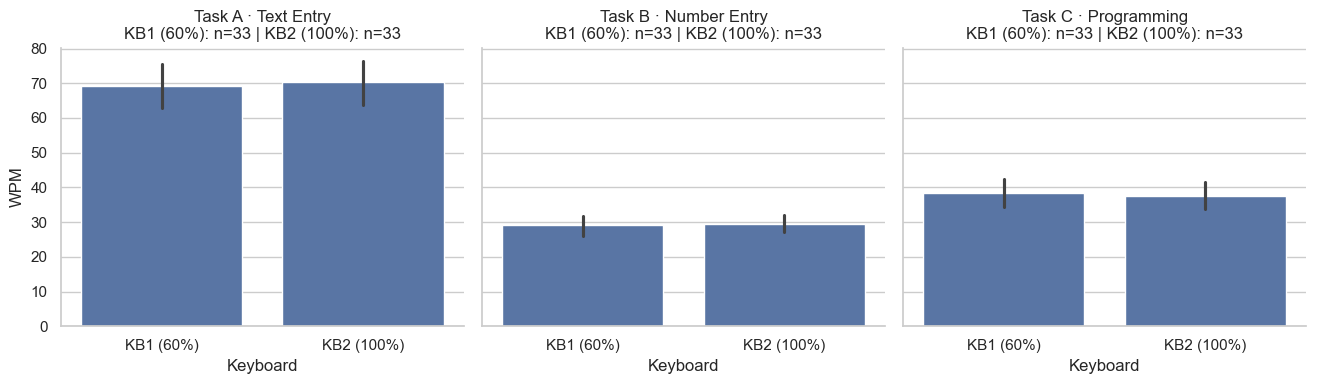

'results/visualizations/bar_WPM_by_keyboard_task.png'

In [271]:
# Bar chart: WPM by keyboard-task combo (saved to results directory)
if "Keyboard" not in perf_long.columns:
    raise KeyError("perf_long is missing the 'Keyboard' column.")

sns.set_theme(style="whitegrid", context="notebook")
g = sns.catplot(
    data=perf_long,
    kind="bar",
    x="Keyboard",
    y="WPM",
    col="Task",
    errorbar=("ci", 95),
    height=4,
    aspect=1.1,
)

for ax, (task_label, sub_df) in zip(g.axes.flatten(), perf_long.groupby("Task", observed=False)):
    counts = sub_df.groupby("Keyboard")["WPM"].count()
    subtitle = " | ".join([f"{kb}: n={int(n)}" for kb, n in counts.items()])
    ax.set_title(f"{task_label}\n{subtitle}")
    ax.set_xlabel("Keyboard")
    ax.set_ylabel("WPM")

plt.tight_layout()
os.makedirs("results/visualizations", exist_ok=True)
keyboard_task_plot_path = "results/visualizations/bar_WPM_by_keyboard_task.png"
g.savefig(keyboard_task_plot_path, dpi=300)
plt.show()

keyboard_task_plot_path


In [272]:
# Accuracy effects and means by keyboard-task combo
if "keyboard_task_results_df" not in globals() or keyboard_task_results_df.empty:
    raise RuntimeError("Run the keyboard-task mixed-effects cell first to populate the summary tables.")

accuracy_effects = keyboard_task_results_df[keyboard_task_results_df["DV"] == "Accuracy"].copy()
print("Keyboard × Task effects for Accuracy:")
display(accuracy_effects)

accuracy_means = keyboard_task_mm_df[keyboard_task_mm_df["DV"] == "Accuracy"].copy()
if accuracy_means.empty:
    raise RuntimeError("Accuracy marginal means were not computed.")

accuracy_table = (
    accuracy_means
    .pivot(index="Task", columns="Keyboard", values="Mean")
    .sort_index()
)
if {"KB1 (60%)", "KB2 (100%)"}.issubset(accuracy_table.columns):
    accuracy_table["Diff_KB2_minus_KB1"] = accuracy_table["KB2 (100%)"] - accuracy_table["KB1 (60%)"]

print("\nMean accuracy (%) by task and keyboard (positive diff means KB2 is more accurate):")
display(accuracy_table.round(2))

# Highlight Task B comparison explicitly
if not accuracy_table.empty:
    task_b_label = next((label for label in accuracy_table.index if "Task B" in label), None)
    if task_b_label is not None:
        task_b_row = accuracy_table.loc[task_b_label]
        kb1 = task_b_row.get("KB1 (60%)", float("nan"))
        kb2 = task_b_row.get("KB2 (100%)", float("nan"))
        diff = task_b_row.get("Diff_KB2_minus_KB1", kb2 - kb1)
        print(
            f"Task B · Number Entry accuracy → KB1 mean = {kb1:.2f}%, KB2 mean = {kb2:.2f}%, "
            f"KB2-KB1 = {diff:.2f} percentage points"
        )
    else:
        print("Task B label not found in Accuracy table; double-check task naming.")


Keyboard × Task effects for Accuracy:


,DV,Effect,F,p,df_num,df_den,eta_p2
3,Accuracy,Keyboard,0.482704,0.488208,1.0,160.0,0.003008
4,Accuracy,Task,6.191380,0.002571,2.0,160.0,0.071833
5,Accuracy,Keyboard:Task,0.014391,0.985714,2.0,160.0,0.000180



Mean accuracy (%) by task and keyboard (positive diff means KB2 is more accurate):


Keyboard,KB1 (60%),KB2 (100%),Diff_KB2_minus_KB1
Task,,,
Task A · Text Entry,92.28,90.99,-1.28
Task B · Number Entry,85.94,85.10,-0.84
Task C · Programming,87.87,86.80,-1.07


Task B · Number Entry accuracy → KB1 mean = 85.94%, KB2 mean = 85.10%, KB2-KB1 = -0.84 percentage points


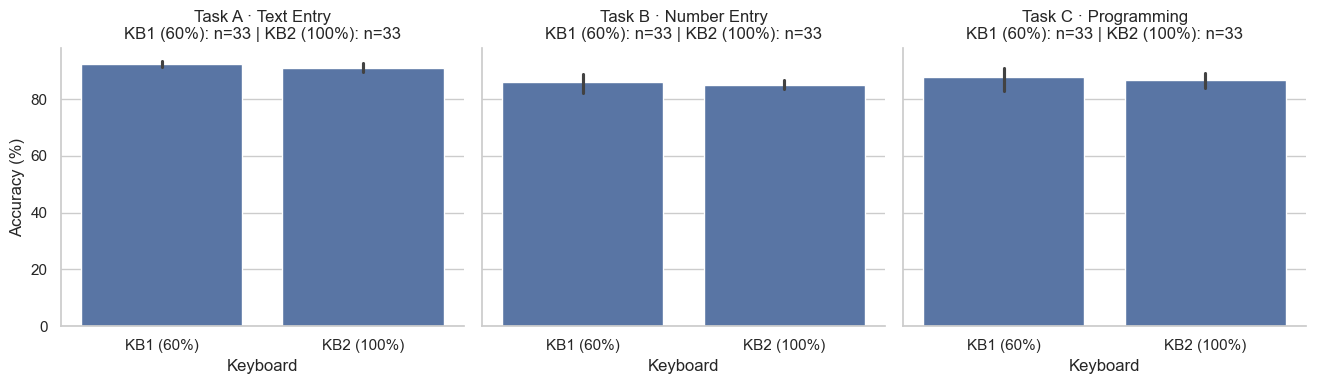

'results/visualizations/bar_Accuracy_by_keyboard_task.png'

In [273]:
# Bar chart: Accuracy by keyboard-task combo (saved to results directory)
sns.set_theme(style="whitegrid", context="notebook")
acc_plot = sns.catplot(
    data=perf_long,
    kind="bar",
    x="Keyboard",
    y="Accuracy",
    col="Task",
    errorbar=("ci", 95),
    height=4,
    aspect=1.1,
)

for ax, (task_label, sub_df) in zip(acc_plot.axes.flatten(), perf_long.groupby("Task", observed=False)):
    counts = sub_df.groupby("Keyboard")["Accuracy"].count()
    subtitle = " | ".join([f"{kb}: n={int(n)}" for kb, n in counts.items()])
    ax.set_title(f"{task_label}\n{subtitle}")
    ax.set_xlabel("Keyboard")
    ax.set_ylabel("Accuracy (%)")

plt.tight_layout()
os.makedirs("results/visualizations", exist_ok=True)
accuracy_plot_path = "results/visualizations/bar_Accuracy_by_keyboard_task.png"
acc_plot.savefig(accuracy_plot_path, dpi=300)
plt.show()

accuracy_plot_path


aaaaaaaaa divider

### $H_{5}$ - Preference and Familiarity

Prepare dependent variables for mixed-effects models

In [274]:
# Dependent variables grouped by interpretation
perf_higher_better = ["WPM", "Accuracy"]
# Treat Backspaces and TotalTime as intermediates only, not dependent variables
perf_lower_better = ["ErrorRate"]

nasa_lower_better = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Effort",
    "Frustration Level",
]
# In this study, higher NASA-TLX Performance = better perceived performance
nasa_higher_better = ["Performance"]

all_dvs = (
    perf_higher_better
    + perf_lower_better
    + nasa_lower_better
    + nasa_higher_better
)

# Ensure numeric types
for col in all_dvs:
    if col in perf_tlx.columns:
        perf_tlx[col] = pd.to_numeric(perf_tlx[col], errors="coerce")

# Ensure predictors are categorical / properly coded
perf_tlx["PreferenceMatch"] = perf_tlx["PreferenceMatch"].astype(int)
perf_tlx["TaskCode"] = perf_tlx["TaskCode"].astype("category")
perf_tlx["Participant_Number"] = perf_tlx["Participant Number"].astype("category")

# Quick sanity check
perf_tlx[[
    "Participant Number",
    "Keyboard",
    "TaskCode",
    "PreferenceMatch",
    "WPM",
    "Accuracy",
    "ErrorRate",
]].head()


,Participant Number,Keyboard,TaskCode,PreferenceMatch,WPM,Accuracy,ErrorRate
0,2,KB1 (60%),A,0,89.0,92.4,7.6
1,3,KB1 (60%),A,0,73.7,84.9,15.1
2,4,KB1 (60%),A,0,61.7,89.6,10.4
3,5,KB1 (60%),A,0,68.8,93.5,6.5
4,12,KB1 (60%),A,0,53.1,93.8,6.2


Mixed-effects models: PreferenceMatch × TaskCode

In [275]:
# Mixed-effects models (fixed DV quoting): PreferenceMatch × TaskCode
# Re-run this cell instead of the earlier mixed-model loop if you hit Patsy
# syntax errors for DVs with spaces (e.g., "Mental Demand").

from collections import defaultdict

mixed_results = {}
mm_marginal_means = {}

for dv in all_dvs:
    if dv not in perf_tlx.columns:
        continue

    model_data = perf_tlx[[
        "Participant_Number",
        "PreferenceMatch",
        "TaskCode",
        dv,
    ]].dropna().copy()

    # Use a safely quoted DV name for Patsy when the column has spaces or
    # characters that are not valid Python identifiers (e.g., "Mental Demand").
    if dv.isidentifier():
        dv_term = dv
    else:
        dv_term = f'Q("{dv}")'

    # Mixed-effects model with random intercept for participant
    # DV ~ PreferenceMatch * TaskCode + (1 | Participant_Number)
    formula_mixed = f"{dv_term} ~ PreferenceMatch * C(TaskCode)"
    md = smf.mixedlm(formula_mixed, data=model_data, groups=model_data["Participant_Number"])
    mdf = md.fit(reml=False, method="lbfgs")

    print("\n" + "=" * 80)
    print(f"Mixed-effects model for {dv}")
    print(mdf.summary())

    # Approximate F-tests and partial eta-squared using type III ANOVA from an OLS model
    # with Participant as a fixed blocking factor. This is equivalent to a random intercept
    # in a balanced design and provides standard F-statistics.
    formula_ols = f"{dv_term} ~ C(PreferenceMatch) * C(TaskCode) + C(Participant_Number)"
    ols_model = smf.ols(formula_ols, data=model_data).fit()
    anova_tbl = anova_lm(ols_model, typ=3)

    # Extract rows of interest
    effect_labels = {
        "C(PreferenceMatch)": "PreferenceMatch",
        "C(TaskCode)": "TaskCode",
        "C(PreferenceMatch):C(TaskCode)": "PreferenceMatch:TaskCode",
    }

    ss_error = anova_tbl.loc["Residual", "sum_sq"]
    dv_results = {}

    for row_label, pretty_label in effect_labels.items():
        if row_label not in anova_tbl.index:
            continue
        row = anova_tbl.loc[row_label]
        f_val = row["F"]
        p_val = row["PR(>F)"]
        df_num = row["df"]
        df_den = anova_tbl.loc["Residual", "df"]
        eta_p = np.nan
        if not np.isnan(f_val):
            ss_effect = row["sum_sq"]
            eta_p = ss_effect / (ss_effect + ss_error) if (ss_effect + ss_error) > 0 else np.nan

        dv_results[pretty_label] = {
            "F": float(f_val) if not np.isnan(f_val) else np.nan,
            "p": float(p_val) if not np.isnan(p_val) else np.nan,
            "df_num": float(df_num),
            "df_den": float(df_den),
            "eta_p2": float(eta_p) if not np.isnan(eta_p) else np.nan,
        }

    # Marginal means for PreferenceMatch (collapsing over TaskCode)
    mm = (
        model_data
        .groupby("PreferenceMatch")[dv]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "Mean", "std": "SD", "count": "N"})
    )
    # 95% CI using normal approximation
    mm["SE"] = mm["SD"] / np.sqrt(mm["N"])
    mm["CI_lower"] = mm["Mean"] - 1.96 * mm["SE"]
    mm["CI_upper"] = mm["Mean"] + 1.96 * mm["SE"]

    mixed_results[dv] = dv_results
    mm_marginal_means[dv] = mm

# Convert mixed model results to a tidy table and save
rows = []
for dv, effects in mixed_results.items():
    for effect_name, stats_dict in effects.items():
        rows.append({
            "DV": dv,
            "Effect": effect_name,
            **stats_dict,
        })

mixed_results_df = pd.DataFrame(rows)

os.makedirs("results/csvs", exist_ok=True)
mixed_results_df.to_csv("results/csvs/mixed_model_results.csv", index=False)

# Also save marginal means
mm_rows = []
for dv, table in mm_marginal_means.items():
    for pref, row in table.iterrows():
        mm_rows.append({
            "DV": dv,
            "PreferenceMatch": int(pref),
            "Mean": row["Mean"],
            "SD": row["SD"],
            "N": int(row["N"]),
            "SE": row["SE"],
            "CI_lower": row["CI_lower"],
            "CI_upper": row["CI_upper"],
        })

mm_df = pd.DataFrame(mm_rows)
mm_df.to_csv("results/csvs/marginal_means_preference.csv", index=False)

mixed_results_df.head()



Mixed-effects model for WPM
                     Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         WPM      
No. Observations:         186             Method:                     ML       
No. Groups:               31              Scale:                      72.2354  
Min. group size:          6               Log-Likelihood:             -698.6984
Max. group size:          6               Converged:                  Yes      
Mean group size:          6.0                                                  
-------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------
Intercept                         67.035    2.360  28.405 0.000  62.410  71.661
C(TaskCode)[T.B]                 -37.550    1.855 -20.246 0.000 -41.185 -33.915
C(TaskCode)[T.C]                

/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Mixed-effects model for ErrorRate
                   Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       ErrorRate
No. Observations:         186           Method:                   ML       
No. Groups:               31            Scale:                    13.4134  
Min. group size:          6             Log-Likelihood:           -529.8465
Max. group size:          6             Converged:                Yes      
Mean group size:          6.0                                              
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         8.365    0.781 10.715 0.000  6.835  9.895
C(TaskCode)[T.B]                  6.236    0.799  7.802 0.000  4.669  7.802
C(TaskCode)[T.C]                  2.262    0.799  2.830 0.005  0.695  3.

/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Mixed-effects model for Frustration Level
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Q("Frustration Level")
No. Observations:    186       Method:               ML                    
No. Groups:          31        Scale:                2.3100                
Min. group size:     6         Log-Likelihood:       -367.9237             
Max. group size:     6         Converged:            Yes                   
Mean group size:     6.0                                                   
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         2.387    0.335  7.137 0.000  1.732  3.043
C(TaskCode)[T.B]                  2.167    0.332  6.533 0.000  1.517  2.817
C(TaskCode)[T.C]                  1.143    0.332  3.446 0.001  0

,DV,Effect,F,p,df_num,df_den,eta_p2
0,WPM,PreferenceMatch,4.423811,3.710994e-02,1.0,150.0,0.028647
1,WPM,TaskCode,217.924418,4.196881e-45,2.0,150.0,0.743961
2,WPM,PreferenceMatch:TaskCode,2.441120,9.051552e-02,2.0,150.0,0.031522
3,Accuracy,PreferenceMatch,0.001005,9.747530e-01,1.0,150.0,0.000007
4,Accuracy,TaskCode,6.063452,2.935708e-03,2.0,150.0,0.074799


In [276]:
### Visualizations: PreferenceMatch effects

sns.set_theme(style="whitegrid", context="notebook")

# 4.1 Summary bar charts: DV mean by PreferenceMatch, faceted by TaskCode
for dv in all_dvs:
    if dv not in perf_tlx.columns:
        continue

    g = sns.catplot(
        data=perf_tlx,
        kind="bar",
        x="PreferenceMatch",
        y=dv,
        col="TaskCode",
        errorbar=("ci", 95),  # use new errorbar API
        height=4,
        aspect=0.9,
    )

    # Add sample sizes in titles
    for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode", observed=False)):
        counts = sub_df.groupby("PreferenceMatch")[dv].count()
        label_parts = [f"Pref={k}: n={v}" for k, v in counts.items()]
        ax.set_title(f"Task {task_code} | " + ", ".join(label_parts))
        ax.set_xlabel("PreferenceMatch (0 = No Match, 1 = Match)")

    g.figure.suptitle(f"Mean {dv} by PreferenceMatch and TaskCode", y=1.05)
    plt.tight_layout()
    os.makedirs("results/visualizations", exist_ok=True)
    out_path = f"results/visualizations/bar_{dv.replace(' ', '_')}_by_preference_task.png"
    g.savefig(out_path, dpi=300)
    plt.close(g.figure)


# 4.2 Interaction plots: TaskCode × PreferenceMatch
for dv in all_dvs:
    if dv not in perf_tlx.columns:
        continue

    plt.figure(figsize=(6, 4))
    ax = sns.pointplot(
        data=perf_tlx,
        x="TaskCode",
        y=dv,
        hue="PreferenceMatch",
        dodge=True,
        markers=["o", "s"],
        linestyles=["--", "-"],
        errorbar=("ci", 95),
        palette="Set1",
    )
    ax.set_title(f"Interaction: TaskCode × PreferenceMatch on {dv}")
    ax.set_ylabel(dv)
    ax.set_xlabel("TaskCode")
    ax.legend(title="PreferenceMatch (0 = No, 1 = Yes)")
    plt.tight_layout()

    os.makedirs("results/visualizations", exist_ok=True)
    out_path = f"results/visualizations/interaction_{dv.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=300)
    plt.close()


# 4.3 Distribution plots (box/violin + points) for key metrics
key_dists = ["WPM", "Accuracy", "Mental Demand", "Physical Demand", "Performance"]

for dv in key_dists:
    if dv not in perf_tlx.columns:
        continue

    g = sns.catplot(
        data=perf_tlx,
        x="PreferenceMatch",
        y=dv,
        col="TaskCode",
        kind="violin",
        inner=None,
        height=4,
        aspect=0.9,
    )

    # Overlay individual points
    for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode", observed=False)):
        sns.stripplot(
            data=sub_df,
            x="PreferenceMatch",
            y=dv,
            dodge=True,
            alpha=0.6,
            color="k",
            size=3,
            ax=ax,
        )
        ax.set_title(f"Task {task_code}")
        ax.set_xlabel("PreferenceMatch (0 = No Match, 1 = Match)")

    g.figure.suptitle(f"Distribution of {dv} by PreferenceMatch and TaskCode", y=1.05)
    plt.tight_layout()

    os.makedirs("results/visualizations", exist_ok=True)
    out_path = f"results/visualizations/dist_{dv.replace(' ', '_')}_by_preference_task.png"
    g.savefig(out_path, dpi=300)
    plt.close(g.figure)


# 4.4 Sample size summary plots
sample_counts = (
    perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=sample_counts,
    x="TaskCode",
    y="N",
    hue="PreferenceMatch",
    palette="Set2",
)
ax.set_title("Sample sizes by PreferenceMatch and TaskCode")
ax.set_ylabel("Number of observations")
ax.set_xlabel("TaskCode")
ax.legend(title="PreferenceMatch (0 = No, 1 = Yes)")
plt.tight_layout()
os.makedirs("results/visualizations", exist_ok=True)
plt.savefig("results/visualizations/sample_sizes_preference_task.png", dpi=300)
plt.close()

sample_counts


/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_27744/1375517567.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")


,PreferenceMatch,TaskCode,N
0,0,A,42
1,0,B,42
2,0,C,42
3,1,A,20
4,1,B,20
5,1,C,20


In [277]:
### Summary report generation

# 1. Sample overview
n_participants = perf_tlx["Participant Number"].nunique()

# Participants whose original keyboard allows a PreferenceMatch = 1 on at least one condition
participant_pref = (
    perf_tlx.groupby("Participant Number")["PreferenceMatch"].max().reset_index()
)
participants_with_match_possible = (participant_pref["PreferenceMatch"] == 1).sum()
participants_without_match = n_participants - participants_with_match_possible

obs_counts = perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")
obs_total = len(perf_tlx)

# 2. Statistical results table (pivoted from mixed_results_df)
results_wide = (
    mixed_results_df
    .pivot_table(
        index="DV",
        columns="Effect",
        values=["F", "p", "eta_p2"],
    )
)
# Flatten MultiIndex columns
results_wide.columns = [f"{m}_{e}" for m, e in results_wide.columns]
results_wide = results_wide.reset_index()

os.makedirs("results/csvs", exist_ok=True)
results_wide.to_csv("results/csvs/statistical_results_table.csv", index=False)

# 3. Key findings: identify significant effects (p < 0.05)
alpha = 0.05

sig_pref = mixed_results_df[
    (mixed_results_df["Effect"] == "PreferenceMatch") & (mixed_results_df["p"] < alpha)
]
sig_task = mixed_results_df[
    (mixed_results_df["Effect"] == "TaskCode") & (mixed_results_df["p"] < alpha)
]
sig_inter = mixed_results_df[
    (mixed_results_df["Effect"] == "PreferenceMatch:TaskCode") & (mixed_results_df["p"] < alpha)
]

# Helper to format mean differences with CIs for a given DV
from textwrap import indent

mm_df_pivot = mm_df.pivot_table(
    index="DV",
    columns="PreferenceMatch",
    values=["Mean", "CI_lower", "CI_upper"],
)


def format_mm_line(dv: str) -> str:
    if dv not in mm_df_pivot.index:
        return ""
    row = mm_df_pivot.loc[dv]
    try:
        mean0 = row["Mean"][0]
        l0 = row["CI_lower"][0]
        u0 = row["CI_upper"][0]
        mean1 = row["Mean"][1]
        l1 = row["CI_lower"][1]
        u1 = row["CI_upper"][1]
    except KeyError:
        return ""
    return (
        f"{dv}: Pref=0 mean={mean0:.2f} [{l0:.2f}, {u0:.2f}], "
        f"Pref=1 mean={mean1:.2f} [{l1:.2f}, {u1:.2f}]"
    )


# 4. Assemble human-readable report
lines = []
lines.append("Keyboard Preference Matching: Mixed-Effects Analysis Report")
lines.append("".join(["="] * len(lines[-1])))
lines.append("")

# Sample overview
lines.append("1. Sample Overview")
lines.append(f"- Total participants: {n_participants}")
lines.append(
    f"- Participants with at least one PreferenceMatch=1 condition: {participants_with_match_possible}"
)
lines.append(
    f"- Participants with PreferenceMatch=0 only: {participants_without_match}"
)
lines.append(f"- Total observations (rows in perf_tlx): {obs_total}")
lines.append("- Observations by PreferenceMatch × TaskCode:")
for _, row in obs_counts.iterrows():
    lines.append(
        f"  - PreferenceMatch={int(row['PreferenceMatch'])}, TaskCode={row['TaskCode']}: N={int(row['N'])}"
    )
lines.append("")

# Statistical results summary
lines.append("2. Statistical Results (mixed models with participant random intercept)")
lines.append("- See 'results/csvs/mixed_model_results.csv' and 'results/csvs/statistical_results_table.csv' for full details.")
lines.append("")

# Key findings
lines.append("3. Key Findings (p < 0.05)")

if not sig_pref.empty:
    lines.append("- Dependent variables with a significant main effect of PreferenceMatch:")
    for dv in sig_pref["DV"].unique():
        sub = sig_pref[sig_pref["DV"] == dv].iloc[0]
        line = (
            f"  - {dv}: F({sub['df_num']:.0f}, {sub['df_den']:.0f}) = {sub['F']:.2f}, "
            f"p = {sub['p']:.3f}, partial eta² = {sub['eta_p2']:.3f}"
        )
        mm_line = format_mm_line(dv)
        if mm_line:
            line += f"; {mm_line}"
        lines.append(line)
else:
    lines.append("- No dependent variables showed a significant main effect of PreferenceMatch.")

if not sig_task.empty:
    lines.append("- Dependent variables with a significant main effect of TaskCode:")
    for dv in sig_task["DV"].unique():
        sub = sig_task[sig_task["DV"] == dv].iloc[0]
        lines.append(
            f"  - {dv}: F({sub['df_num']:.0f}, {sub['df_den']:.0f}) = {sub['F']:.2f}, "
            f"p < 0.05, partial eta² = {sub['eta_p2']:.3f}"
        )
else:
    lines.append("- No dependent variables showed a significant main effect of TaskCode.")

if not sig_inter.empty:
    lines.append("- Dependent variables with a significant PreferenceMatch × TaskCode interaction:")
    for dv in sig_inter["DV"].unique():
        sub = sig_inter[sig_inter["DV"] == dv].iloc[0]
        lines.append(
            f"  - {dv}: F({sub['df_num']:.0f}, {sub['df_den']:.0f}) = {sub['F']:.2f}, "
            f"p = {sub['p']:.3f}, partial eta² = {sub['eta_p2']:.3f}"
        )
else:
    lines.append("- No dependent variables showed a significant PreferenceMatch × TaskCode interaction.")

lines.append("")

# 4. Interpretation placeholder (you can refine wording after inspecting actual results)
lines.append("4. Interpretation (high-level)")
lines.append(
    "- Performance metrics where higher is better (WPM, Accuracy, TLX Performance) and lower is better (ErrorRate, Backspaces, TotalTime) "
    "can be interpreted directly using the marginal means reported above."
)
lines.append(
    "- NASA-TLX workload dimensions (Mental, Physical, Temporal Demand, Effort, Frustration) should decrease when the keyboard matches "
    "participant preference if preference matching reduces workload."
)
lines.append(
    "- Use the significant PreferenceMatch and interaction effects (if any) to support claims about whether matching the participant's "
    "preferred layout improves objective performance and/or reduces subjective workload, and whether these patterns differ by task type."
)

report_text = "\n".join(lines)

os.makedirs("results/texts", exist_ok=True)
with open("results/texts/summary_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)


Keyboard Preference Matching: Mixed-Effects Analysis Report

1. Sample Overview
- Total participants: 31
- Participants with at least one PreferenceMatch=1 condition: 19
- Participants with PreferenceMatch=0 only: 12
- Total observations (rows in perf_tlx): 186
- Observations by PreferenceMatch × TaskCode:
  - PreferenceMatch=0, TaskCode=A: N=42
  - PreferenceMatch=0, TaskCode=B: N=42
  - PreferenceMatch=0, TaskCode=C: N=42
  - PreferenceMatch=1, TaskCode=A: N=20
  - PreferenceMatch=1, TaskCode=B: N=20
  - PreferenceMatch=1, TaskCode=C: N=20

2. Statistical Results (mixed models with participant random intercept)
- See 'results/csvs/mixed_model_results.csv' and 'results/csvs/statistical_results_table.csv' for full details.

3. Key Findings (p < 0.05)
- Dependent variables with a significant main effect of PreferenceMatch:
  - WPM: F(1, 150) = 4.42, p = 0.037, partial eta² = 0.029; WPM: Pref=0 mean=44.20 [40.42, 47.97], Pref=1 mean=47.68 [41.89, 53.46]
  - Mental Demand: F(1, 150) = 7.3

/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_27744/1809001569.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_counts = perf_tlx.groupby(["PreferenceMatch", "TaskCode"]).size().reset_index(name="N")


#### PreferenceMatch × TaskCode: Key performance plots (inline)

The cells below re-create a subset of the preference visualizations **inline** (no files written),
with a small number of plots per cell so it is easier to see what is going on.

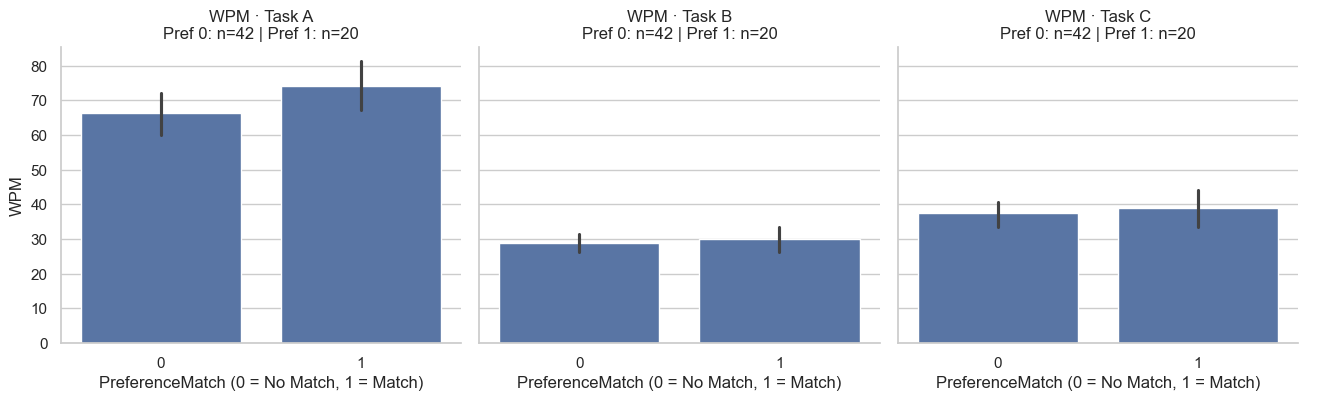

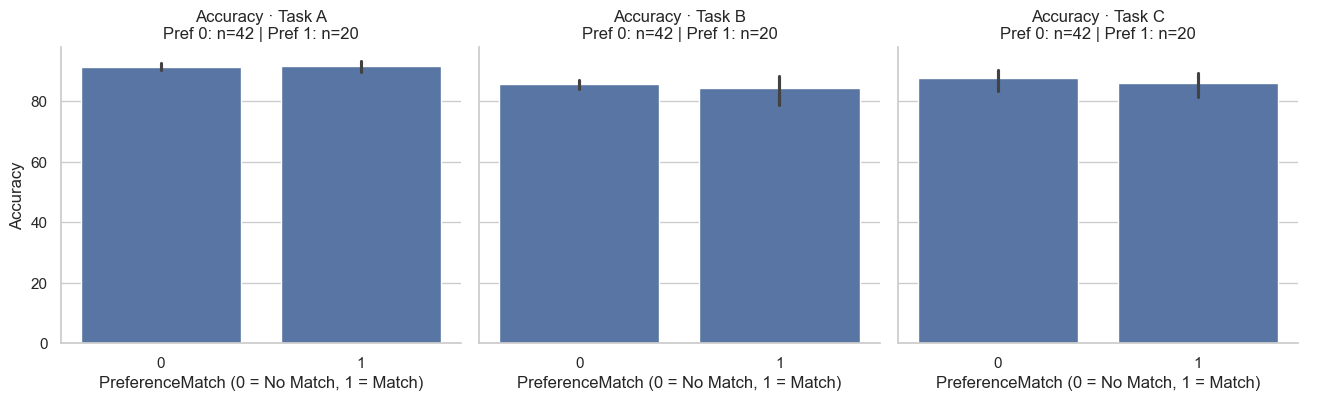

In [278]:
# Bar plots: WPM and Accuracy by PreferenceMatch × TaskCode (inline display only)

sns.set_theme(style="whitegrid", context="notebook")

for dv in ["WPM", "Accuracy"]:
    if dv not in perf_tlx.columns:
        continue

    g = sns.catplot(
        data=perf_tlx,
        kind="bar",
        x="PreferenceMatch",
        y=dv,
        col="TaskCode",
        errorbar=("ci", 95),
        height=4,
        aspect=1.1,  # a bit wider facets for readability
    )

    # Add sample sizes in titles, formatted across two lines to avoid overlap
    for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode", observed=False)):
        counts = sub_df.groupby("PreferenceMatch")[dv].count()
        # Ensure both levels 0 and 1 are shown even if one is missing
        n0 = int(counts.get(0, 0))
        n1 = int(counts.get(1, 0))
        title_line1 = f"{dv} · Task {task_code}"
        title_line2 = f"Pref 0: n={n0} | Pref 1: n={n1}"
        ax.set_title(f"{title_line1}\n{title_line2}")
        ax.set_xlabel("PreferenceMatch (0 = No Match, 1 = Match)")

    # Rely on per-facet titles only; no global suptitle to keep text from colliding
    plt.show()


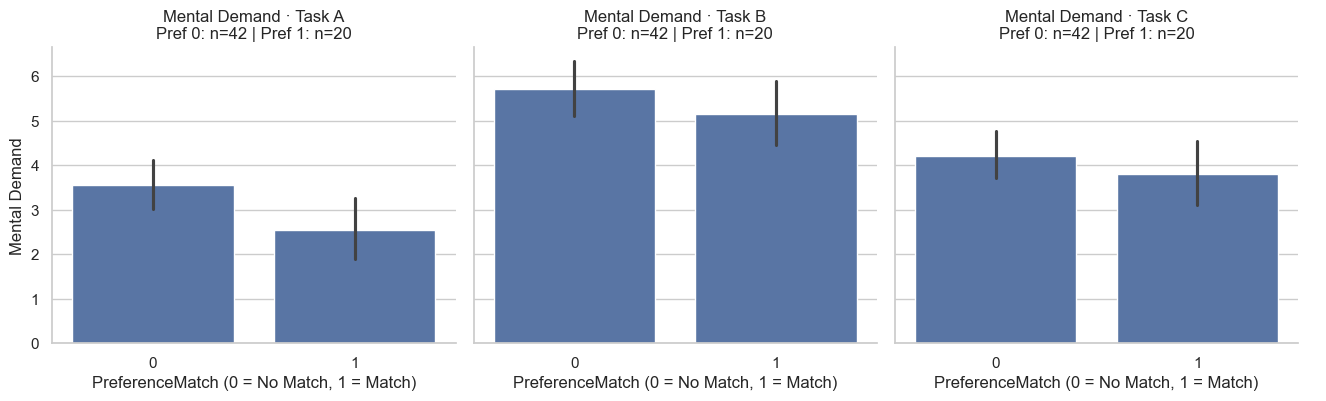

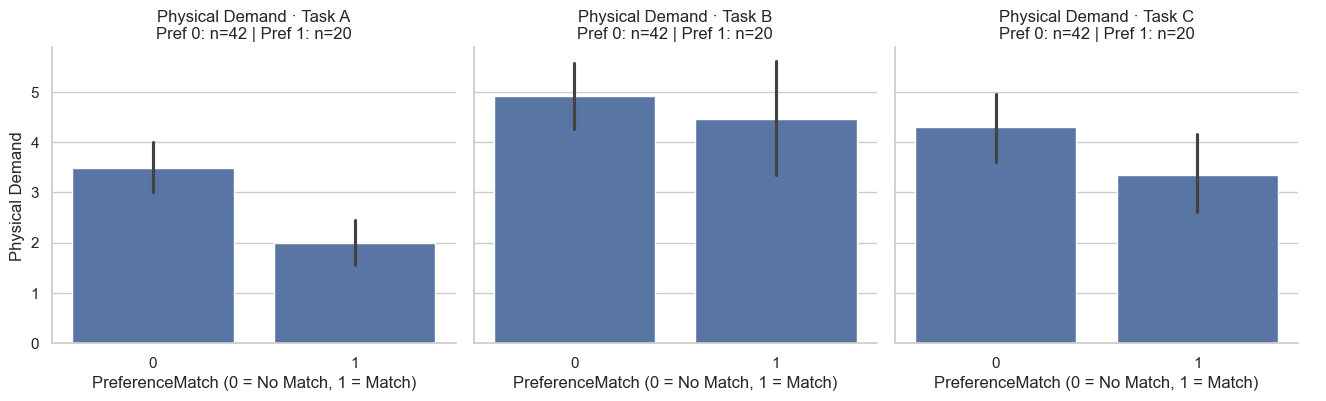

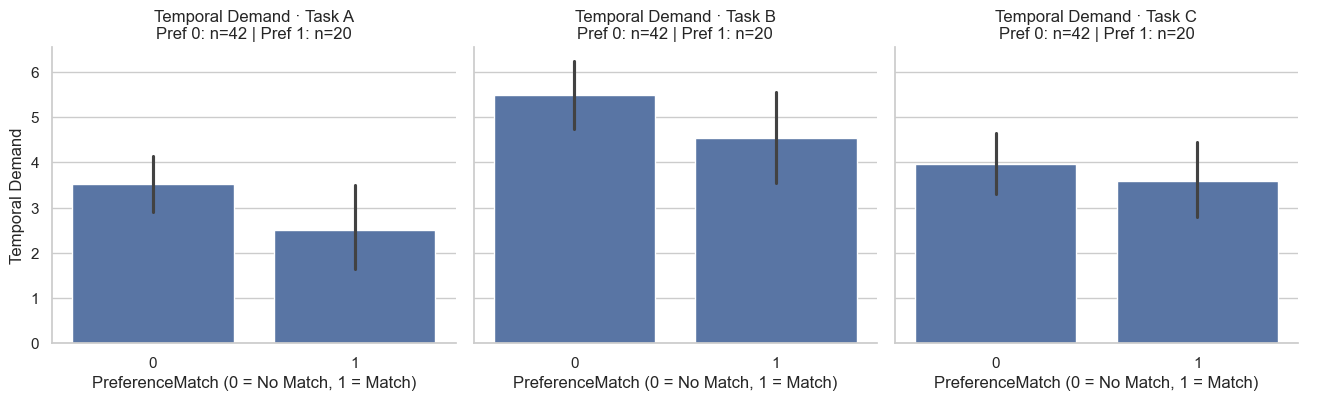

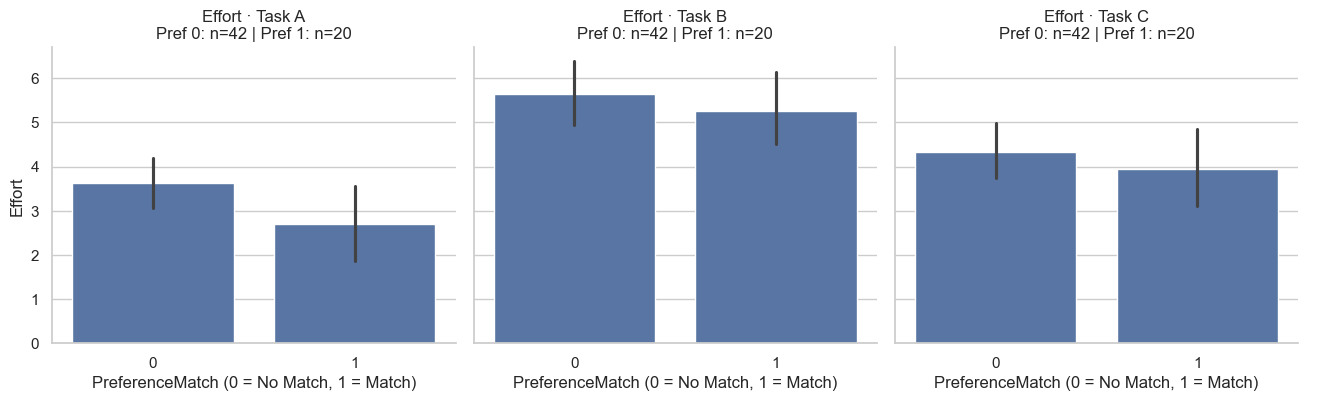

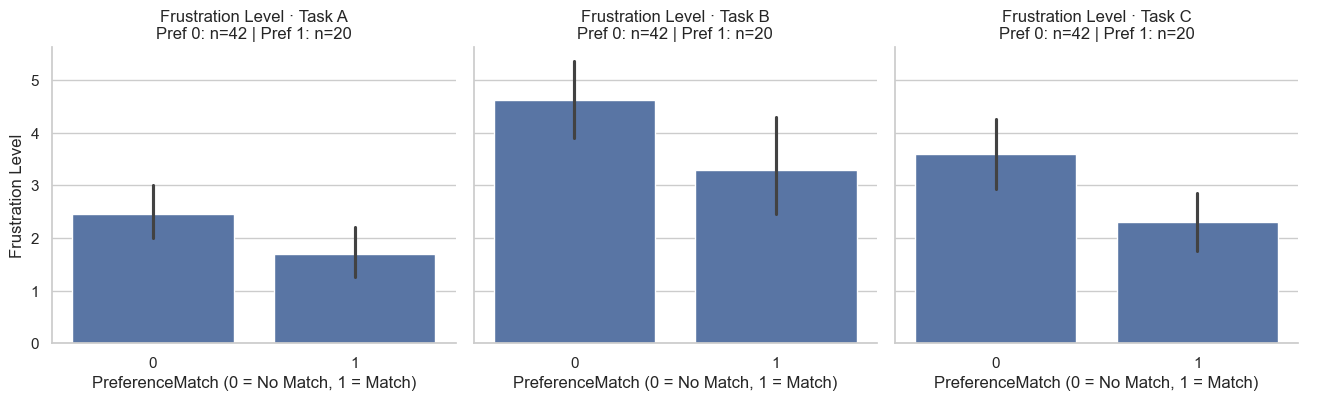

In [279]:
# Bar plots: NASA TLX workload dimensions by PreferenceMatch × TaskCode (inline)

workload_dvs = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Effort",
    "Frustration Level",
]

for dv in workload_dvs:
    if dv not in perf_tlx.columns:
        continue

    g = sns.catplot(
        data=perf_tlx,
        kind="bar",
        x="PreferenceMatch",
        y=dv,
        col="TaskCode",
        errorbar=("ci", 95),
        height=4,
        aspect=1.1,  # slightly wider facets for clearer titles
    )

    # Add sample sizes in two-line titles for readability
    for ax, (task_code, sub_df) in zip(g.axes.flatten(), perf_tlx.groupby("TaskCode", observed=False)):
        counts = sub_df.groupby("PreferenceMatch")[dv].count()
        n0 = int(counts.get(0, 0))
        n1 = int(counts.get(1, 0))
        title_line1 = f"{dv} · Task {task_code}"
        title_line2 = f"Pref 0: n={n0} | Pref 1: n={n1}"
        ax.set_title(f"{title_line1}\n{title_line2}")
        ax.set_xlabel("PreferenceMatch (0 = No Match, 1 = Match)")

    # Rely only on per-facet titles to avoid overlapping with a global suptitle
    plt.show()


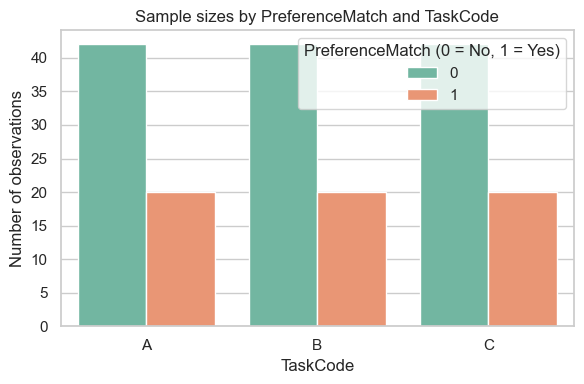

,PreferenceMatch,TaskCode,N
0,0,A,42
1,0,B,42
2,0,C,42
3,1,A,20
4,1,B,20
5,1,C,20


In [280]:
# Sample size bar plot: PreferenceMatch × TaskCode (inline)

sample_counts = (
    perf_tlx.groupby(["PreferenceMatch", "TaskCode"], observed=False).size().reset_index(name="N")
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=sample_counts,
    x="TaskCode",
    y="N",
    hue="PreferenceMatch",
    palette="Set2",
)
ax.set_title("Sample sizes by PreferenceMatch and TaskCode")
ax.set_ylabel("Number of observations")
ax.set_xlabel("TaskCode")
ax.legend(title="PreferenceMatch (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

sample_counts


## Conclusions and insights from all the hypotheses and data.
- TODO: Fill this up with conclusions.

### Relationship between Typing Performance and NASA-TLX Scores
Note to self: Does this matter?

The graph below shows that higher WPM seems to correlate to lower perceived workload. This could be because people who type faster perceive the task to also be easier.

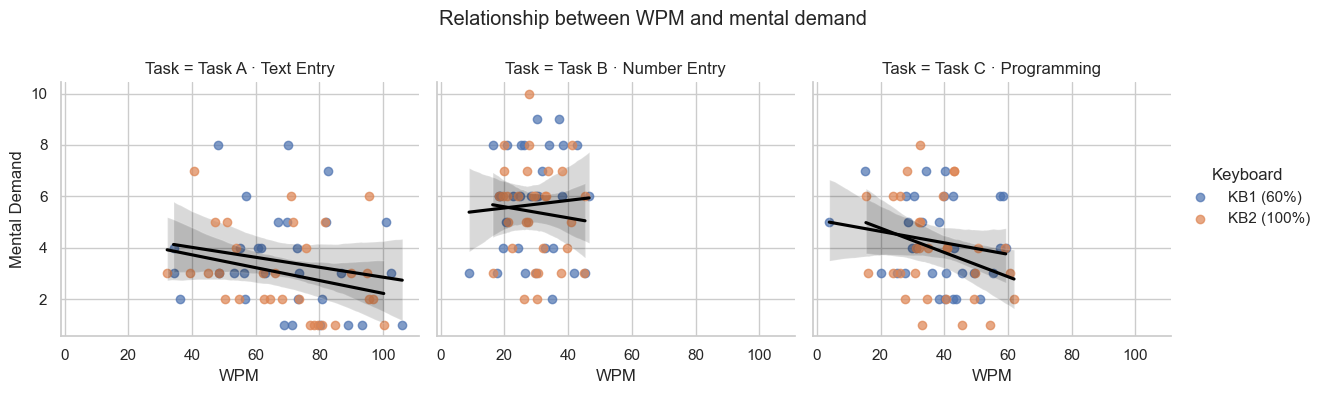

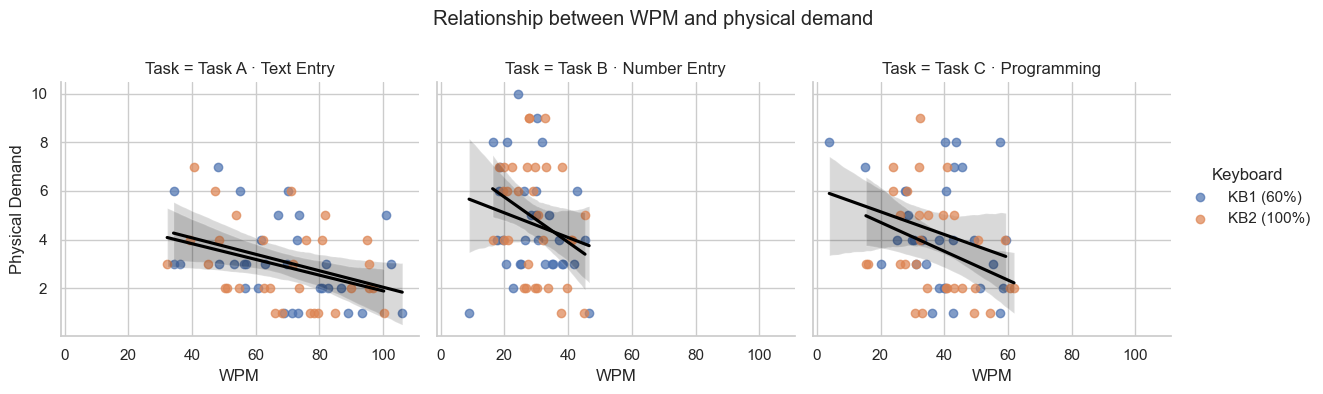

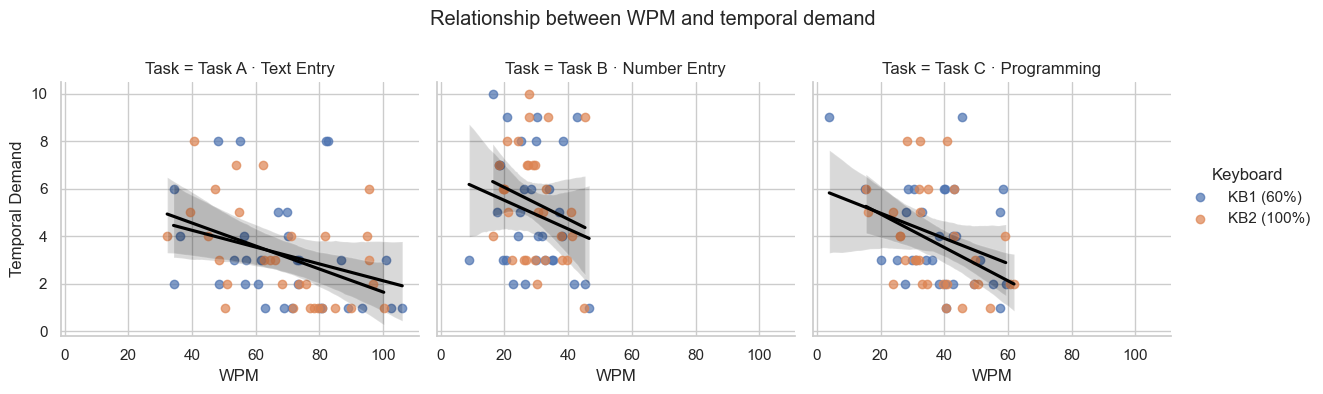

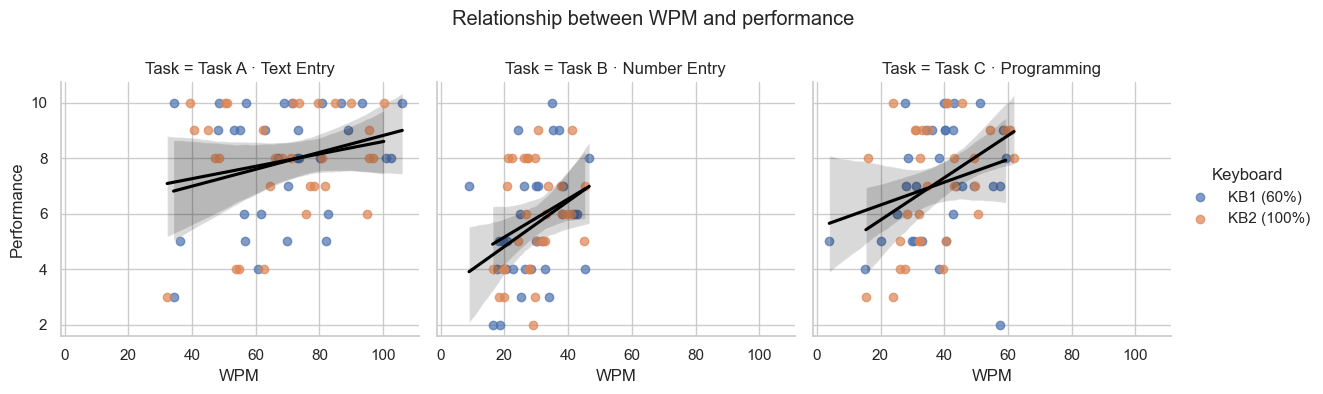

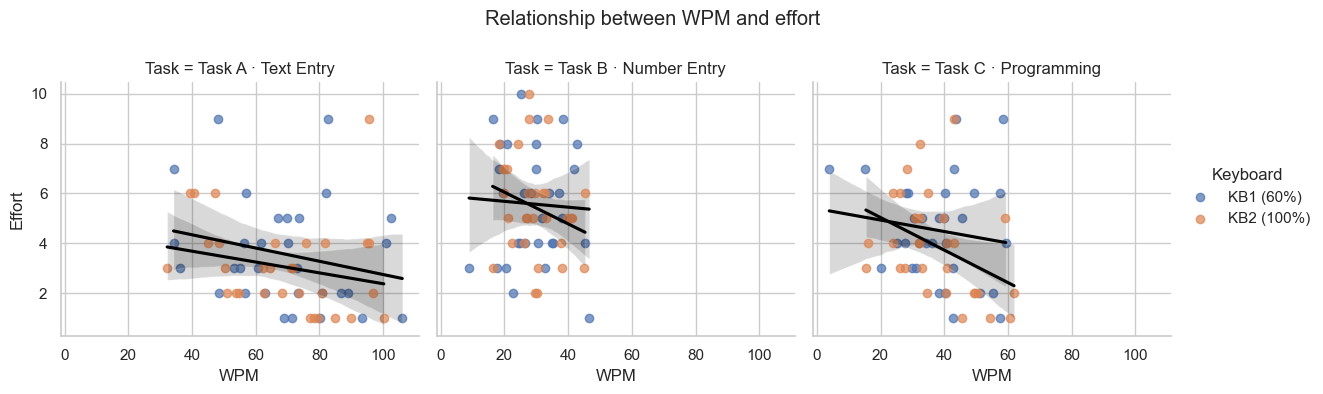

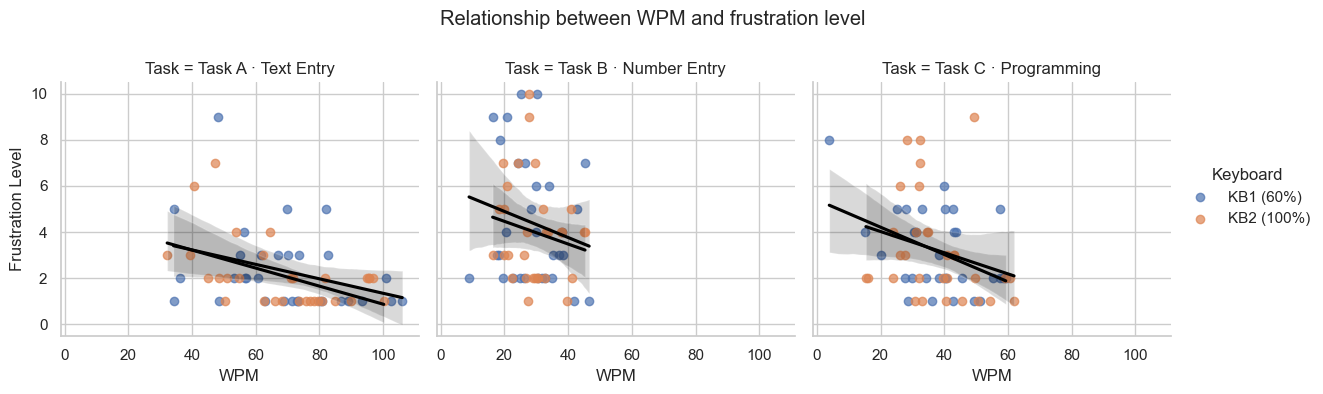

In [281]:
x = "WPM"
for dim in workload_cols:
    g = sns.lmplot(
        data=perf_tlx,
        x=x,
        y=dim,
        hue="Keyboard",
        col="Task",
        height=4,
        aspect=1,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "black"},
    )
    g.figure.subplots_adjust(top=0.8)
    g.figure.suptitle(f"Relationship between {x} and {dim.lower()}")
    plt.show()


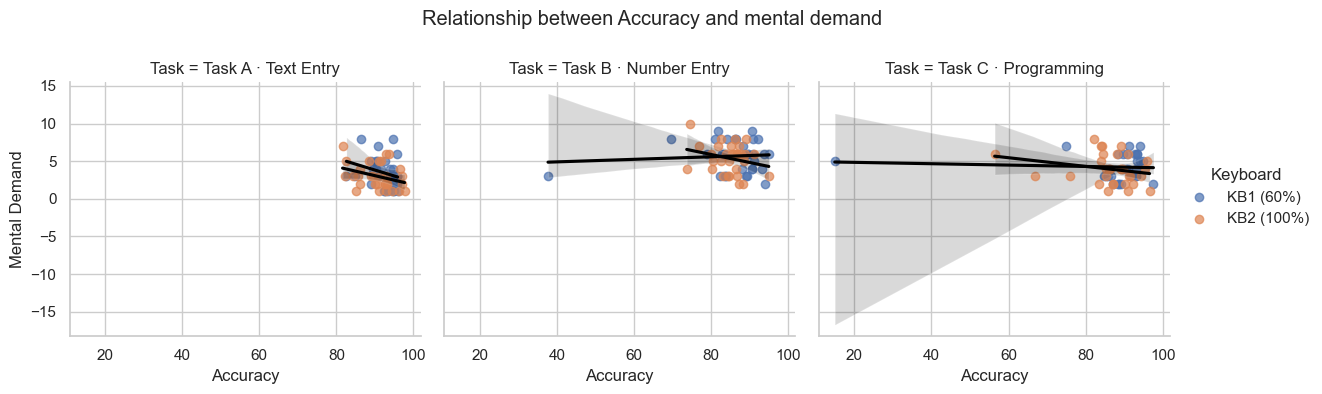

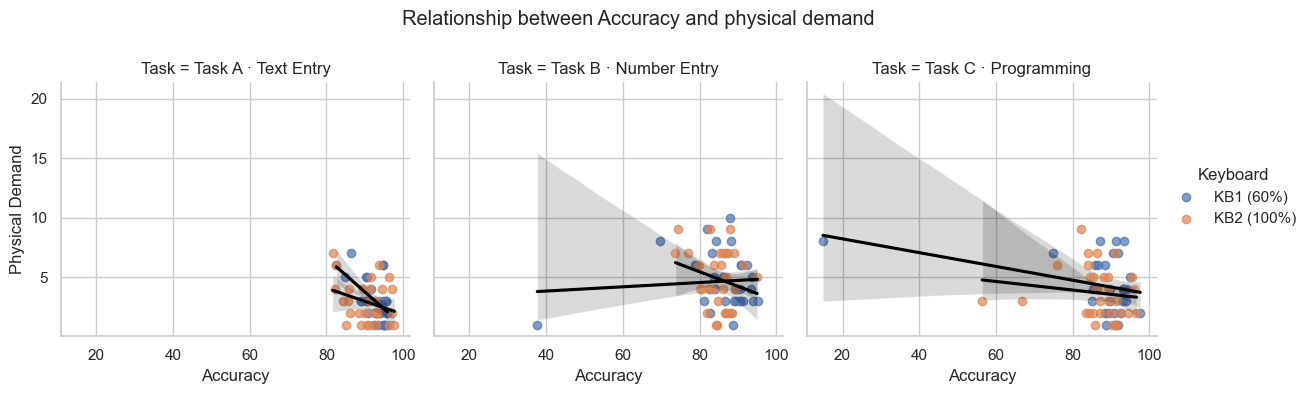

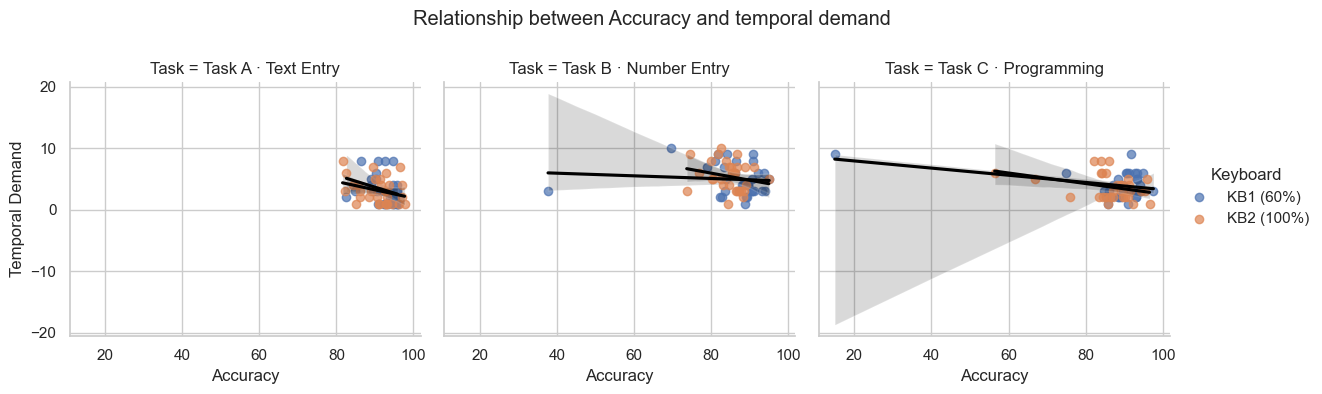

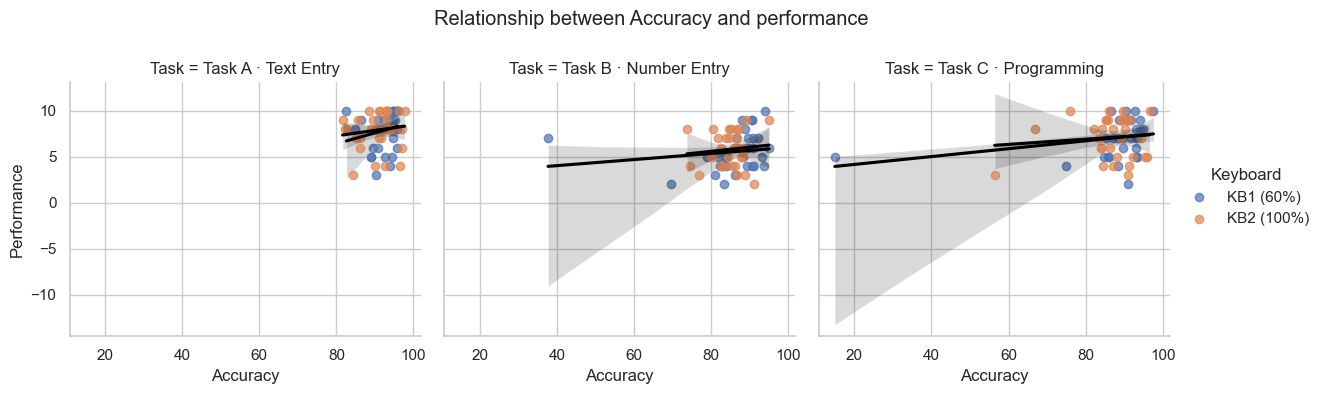

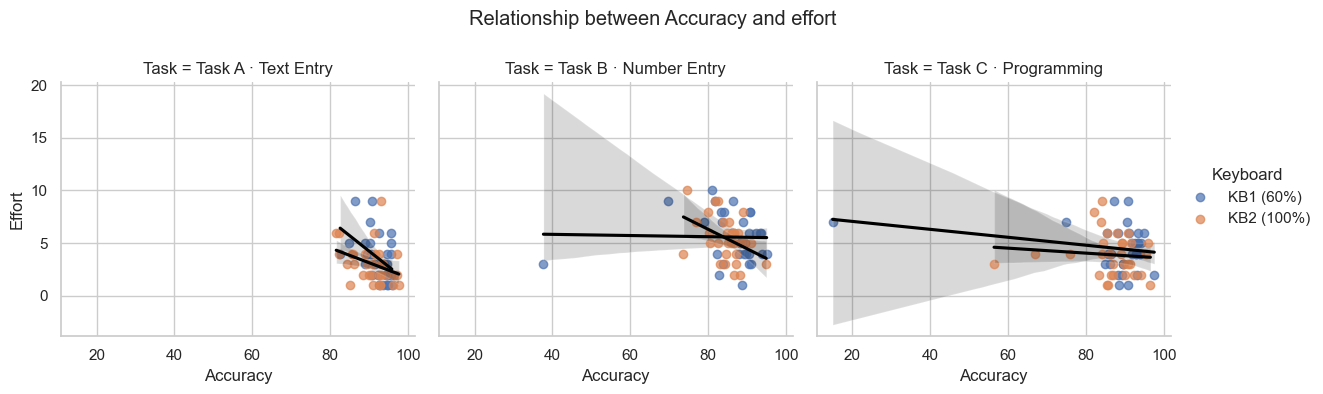

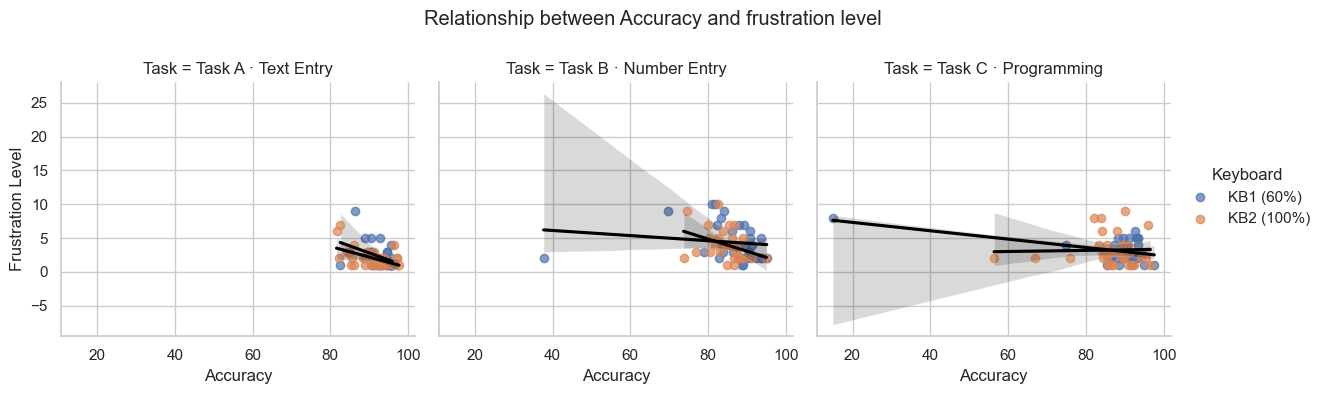

In [282]:
x = "Accuracy"
for dim in workload_cols:
    g = sns.lmplot(
        data=perf_tlx,
        x=x,
        y=dim,
        hue="Keyboard",
        col="Task",
        height=4,
        aspect=1,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "black"},
    )
    g.figure.subplots_adjust(top=0.8)
    g.figure.suptitle(f"Relationship between {x} and {dim.lower()}")
    plt.show()


## Quick Results Migration

### Export repeated-measures ANOVA tables to Excel

The following cell collates the pingouin-based repeated-measures ANOVA source
tables for H0–H3 (WPM, Accuracy, Error Rate, Raw TLX) into a single Excel file
(one sheet), with each hypothesis written as its own labeled block separated by
blank rows.


In [283]:
# Compile and export repeated-measures ANOVA source tables for H0–H3

results_dir = "results/excel"
os.makedirs(results_dir, exist_ok=True)

rm_tables = []

def _append_rm_block(label, result_dict):
    """Append a labeled RM ANOVA source table (if available) to rm_tables.

    Each block gets a leading 'Hypothesis' column and is followed by a
    single blank row as a visual separator in Excel.
    """
    if not isinstance(result_dict, dict):
        return
    table = result_dict.get("source_table")
    if table is None or table.empty:
        return
    block = table.copy()
    block.insert(0, "Hypothesis", label)
    rm_tables.append(block)
    # Separator row
    sep = pd.DataFrame([[np.nan] * block.shape[1]], columns=block.columns)
    rm_tables.append(sep)

# H0 – WPM
if "wpm_result" in globals():
    _append_rm_block("H0 – WPM", wpm_result)

# H1 – Accuracy
if "accuracy_result" in globals():
    _append_rm_block("H1 – Accuracy", accuracy_result)

# H2 – Error Rate
if "error_rate_result" in globals():
    _append_rm_block("H2 – Error Rate", error_rate_result)

# H3 – Raw TLX workload
if "nasa_rm_results" in globals() and isinstance(nasa_rm_results, dict):
    raw_tlx_res = nasa_rm_results.get("Raw_TLX")
    if raw_tlx_res is not None:
        _append_rm_block("H3 – Raw TLX", raw_tlx_res)

if not rm_tables:
    raise RuntimeError("No repeated-measures ANOVA results found. Run H0–H3 cells first.")

rm_combined = pd.concat(rm_tables, ignore_index=True)
rm_export_path = os.path.join(results_dir, "repeated_measures_anova_tables.xlsx")

# Export to Excel using DataFrame.to_excel() directly
# Try openpyxl first, fall back to xlsxwriter if needed
try:
    rm_combined.to_excel(rm_export_path, sheet_name="RM_ANOVAs", index=False, engine="openpyxl")
except ImportError:
    rm_combined.to_excel(rm_export_path, sheet_name="RM_ANOVAs", index=False, engine="xlsxwriter")

print(f"✓ Repeated-measures ANOVA tables exported to: {rm_export_path}")
rm_export_path


✓ Repeated-measures ANOVA tables exported to: results/excel/repeated_measures_anova_tables.xlsx


'results/excel/repeated_measures_anova_tables.xlsx'